In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
from pathlib import Path

# "Mon Drive" in the UI = MyDrive on disk (the path is always English, no accent)
PROJECT = Path('/content/drive/MyDrive/ICU Twin Synthetic')
assert PROJECT.exists(), f"Not found: {PROJECT}\nCheck the exact folder name and spaces."

print("Project root:", PROJECT, "\n")
for p in sorted(PROJECT.iterdir()):
    tag = "[dir] " if p.is_dir() else "      "
    print(tag, p.name)

Project root: /content/drive/MyDrive/ICU Twin Synthetic 

[dir]  .git
       README.md
       app.py
[dir]  dashboard_bundle
[dir]  data
       download_data.py
       feature_config.json
       icu_base_clean.parquet
       icu_dataset_summary.txt
       icu_features.csv
       prepare_dataset.py


In [13]:
NEEDED = ["icustays.csv", "chartevents.csv", "d_items.csv", "patients.csv", "admissions.csv"]

found = {}
for name in NEEDED:
    hits = list(PROJECT.rglob(name))
    found[name] = hits[0] if hits else None
    status = "OK     " if hits else "MISSING"
    print(f"{status}  {name:16s} -> {hits[0] if hits else '---'}")

assert all(found.values()), "Some source tables are missing — check the data/ folder on Drive."
DATA_DIR = found["chartevents.csv"].parent
print("\nDATA_DIR =", DATA_DIR)

OK       icustays.csv     -> /content/drive/MyDrive/ICU Twin Synthetic/data/mimic-demo/icu/icustays.csv
OK       chartevents.csv  -> /content/drive/MyDrive/ICU Twin Synthetic/data/mimic-demo/icu/chartevents.csv
OK       d_items.csv      -> /content/drive/MyDrive/ICU Twin Synthetic/data/mimic-demo/icu/d_items.csv
OK       patients.csv     -> /content/drive/MyDrive/ICU Twin Synthetic/data/mimic-demo/hosp/patients.csv
OK       admissions.csv   -> /content/drive/MyDrive/ICU Twin Synthetic/data/mimic-demo/hosp/admissions.csv

DATA_DIR = /content/drive/MyDrive/ICU Twin Synthetic/data/mimic-demo/icu


In [14]:
import pandas as pd

icustays = pd.read_csv(found["icustays.csv"], parse_dates=["intime", "outtime"])
patients = pd.read_csv(found["patients.csv"])
d_items  = pd.read_csv(found["d_items.csv"])

print("patients      :", patients.subject_id.nunique(), "unique  (demo should be 100)")
print("ICU stays     :", len(icustays))
print("dictionary rows:", len(d_items))

# chartevents is big — read only the columns we need
ce = pd.read_csv(found["chartevents.csv"],
                 usecols=["stay_id", "itemid", "valuenum", "charttime"],
                 parse_dates=["charttime"])

VITALS = {220045:"HR", 220277:"SpO2", 220210:"RR",
          220052:"MAP arterial", 220181:"MAP non-invasive",
          223762:"Temp °C", 223761:"Temp °F"}

counts = ce[ce.itemid.isin(VITALS)].itemid.value_counts()
print("\nvital readings found in chartevents:")
for iid, name in VITALS.items():
    print(f"   {name:17s} ({iid}): {int(counts.get(iid, 0)):>6d}")

print("\nchartevents total rows:", f"{len(ce):,}")

patients      : 100 unique  (demo should be 100)
ICU stays     : 140
dictionary rows: 4014

vital readings found in chartevents:
   HR                (220045):  13913
   SpO2              (220277):  13540
   RR                (220210):  13913
   MAP arterial      (220052):   5560
   MAP non-invasive  (220181):   8342
   Temp °C           (223762):    391
   Temp °F           (223761):   3379

chartevents total rows: 668,862


In [15]:
import matplotlib.pyplot as plt

feat = pd.read_csv(PROJECT / "icu_features.csv", parse_dates=["bin"])
vitals = ["hr", "spo2", "rr", "map", "temp"]

print("prepared rows :", f"{len(feat):,}")
print("ICU stays     :", feat.stay_id.nunique())
print("patients      :", feat.subject_id.nunique())
print("positive rate :", f"{feat.deterioration_next_3h.mean()*100:.1f}%")

prepared rows : 12,233
ICU stays     : 140
patients      : 100
positive rate : 37.0%


In [16]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

vitals = ["hr", "spo2", "rr", "map", "temp"]
trend  = [f"{v}_{s}" for v in vitals for s in ["d1", "d2", "rollmean", "slope"]]

feat["gender_bin"] = (feat["gender"] == "M").astype(int)
FEATURES = vitals + trend + ["age", "gender_bin"]
TARGET   = "deterioration_next_3h"

X, y, groups = feat[FEATURES], feat[TARGET], feat["stay_id"]

# Split by STAY, never by row — bins from one patient must not straddle the split
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

print(f"train: {len(train_idx):,} rows / {feat.iloc[train_idx].stay_id.nunique()} stays")
print(f"test : {len(test_idx):,} rows / {feat.iloc[test_idx].stay_id.nunique()} stays")
print("stay overlap (must be 0):",
      len(set(feat.iloc[train_idx].stay_id) & set(feat.iloc[test_idx].stay_id)))
print(f"positive rate  train {y.iloc[train_idx].mean()*100:.1f}%  |  test {y.iloc[test_idx].mean()*100:.1f}%")

train: 10,638 rows / 126 stays
test : 1,595 rows / 14 stays
stay overlap (must be 0): 0
positive rate  train 35.4%  |  test 47.9%


In [17]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

y_test = y.iloc[test_idx]

# Majority-class: always predict "stable"
majority = np.zeros(len(y_test))

# Persistence: predict "deteriorates in next 3h" == "is breaching a threshold right now"
persistence = feat.iloc[test_idx]["deteriorated_now"].values

print("MAJORITY-CLASS")
print(f"  accuracy : {(majority == y_test.values).mean():.3f}  (this is just the stable rate)\n")

print("PERSISTENCE  (predict later = now)")
print(f"  ROC-AUC  : {roc_auc_score(y_test, persistence):.3f}")
print(f"  PR-AUC   : {average_precision_score(y_test, persistence):.3f}")
print("  --> any real model has to beat these to justify itself\n")
print(classification_report(y_test, persistence, target_names=["stable", "deteriorates"]))

MAJORITY-CLASS
  accuracy : 0.521  (this is just the stable rate)

PERSISTENCE  (predict later = now)
  ROC-AUC  : 0.648
  PR-AUC   : 0.595
  --> any real model has to beat these to justify itself

              precision    recall  f1-score   support

      stable       0.62      0.87      0.73       831
deteriorates       0.75      0.43      0.55       764

    accuracy                           0.66      1595
   macro avg       0.69      0.65      0.64      1595
weighted avg       0.68      0.66      0.64      1595



In [18]:
from sklearn.model_selection import GroupShuffleSplit

# Rebuild from the source CSV that's definitely on Drive — no dependency on Cell 10.
feat = pd.read_csv(PROJECT / "icu_features.csv", parse_dates=["bin"])
vitals = ["hr", "spo2", "rr", "map", "temp"]

# demographics encoding
feat["gender_bin"] = (feat["gender"] == "M").astype(int)

# reproduce the EXACT same leakage-safe split as Cell 6 (identical seed/params)
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
_tr, _te = next(gss.split(feat, feat["deterioration_next_3h"], feat["stay_id"]))
feat["split"] = "train"
feat.loc[feat.index[_te], "split"] = "test"
print("split rebuilt — train stays:", feat[feat.split=='train'].stay_id.nunique(),
      "| test stays:", feat[feat.split=='test'].stay_id.nunique())

# --- plausibility clipping (implausible vitals -> NaN) ---
RANGES = {"hr": (20, 250), "spo2": (50, 100), "rr": (3, 60),
          "map": (20, 200), "temp": (30, 43)}

clip_report = {}
for v, (lo, hi) in RANGES.items():
    bad = (feat[v] < lo) | (feat[v] > hi)
    clip_report[v] = int(bad.sum())
    feat.loc[bad, v] = np.nan

print("values clipped to NaN (real MIMIC artifacts):")
for v, n in clip_report.items():
    print(f"   {v:5s}: {n}")
print("total:", sum(clip_report.values()), "of", len(feat), "rows")

split rebuilt — train stays: 105 | test stays: 35
values clipped to NaN (real MIMIC artifacts):
   hr   : 2
   spo2 : 2
   rr   : 27
   map  : 29
   temp : 9
total: 69 of 12233 rows


In [19]:
# a missing/clipped reading is itself signal ("we don't have a trustworthy value here")
for v in vitals:
    feat[f"{v}_missing"] = feat[v].isna().astype(int)

# the old _d1/_d2/_rollmean/_slope were computed on UNCLIPPED vitals in prepare_dataset.py.
# drop them — we recompute from clean vitals in the next cell so everything is consistent.
stale = [c for c in feat.columns
         if any(c == f"{v}_{s}" for v in vitals for s in ["d1", "d2", "rollmean", "slope"])]
feat = feat.drop(columns=stale)
print(f"dropped {len(stale)} stale trend columns — will recompute from clean vitals")
print("added missingness flags:", [f"{v}_missing" for v in vitals])

dropped 20 stale trend columns — will recompute from clean vitals
added missingness flags: ['hr_missing', 'spo2_missing', 'rr_missing', 'map_missing', 'temp_missing']


In [20]:
def rolling_slope(s, w):
    """Least-squares slope over a trailing window (units per bin). Causal: past only."""
    a = s.to_numpy(dtype=float)
    out = np.full(len(a), np.nan)
    xf = np.arange(w, dtype=float)
    for i in range(len(a)):
        y = a[max(0, i - w + 1): i + 1]
        x = xf[:len(y)]
        m = ~np.isnan(y)
        if m.sum() >= 2:
            out[i] = np.polyfit(x[m], y[m], 1)[0]
    return out

def engineer_features(df, roll=3):
    """
    Single source of truth for derived features.
    Every operation here is CAUSAL (diff / trailing rolling) and per-stay,
    so it never leaks future or cross-patient info. Add your tricks inside.
    """
    df = df.sort_values(["stay_id", "bin"]).copy()
    g = df.groupby("stay_id")
    for v in vitals:
        df[f"{v}_d1"]       = g[v].diff(1)                                   # 1-bin change
        df[f"{v}_d2"]       = g[v].diff(2)                                   # 2-bin change
        df[f"{v}_rollmean"] = g[v].transform(lambda s: s.rolling(roll, min_periods=1).mean())
        df[f"{v}_slope"]    = g[v].transform(lambda s: rolling_slope(s, roll))
    # <<< YOUR FEATURE-ENGINEERING TRICKS GO HERE (keep them causal + per-stay) >>>
    return df

feat = engineer_features(feat)
print("engineered feature columns rebuilt from clean vitals.")

engineered feature columns rebuilt from clean vitals.


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

trend = [f"{v}_{s}" for v in vitals for s in ["d1", "d2", "rollmean", "slope"]]
miss  = [f"{v}_missing" for v in vitals]
FEATURES = vitals + trend + miss + ["age", "gender_bin"]
TARGET = "deterioration_next_3h"

trm, tem = feat.split == "train", feat.split == "test"
med = feat.loc[trm, FEATURES].median()                 # impute stats from TRAIN only
X_tr, X_te = feat.loc[trm, FEATURES].fillna(med), feat.loc[tem, FEATURES].fillna(med)
y_tr, y_te = feat.loc[trm, TARGET], feat.loc[tem, TARGET]

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                            n_jobs=-1, class_weight="balanced")
rf.fit(X_tr, y_tr)
p = rf.predict_proba(X_te)[:, 1]

print(f"CLEAN BASE — RandomForest")
print(f"  features : {len(FEATURES)}")
print(f"  ROC-AUC  : {roc_auc_score(y_te, p):.3f}   (reference before cleaning: 0.756)")
print(f"  PR-AUC   : {average_precision_score(y_te, p):.3f}   (reference: 0.686)")
print()
print(classification_report(y_te, (p >= 0.5).astype(int), target_names=["stable", "deteriorates"]))

CLEAN BASE — RandomForest
  features : 32
  ROC-AUC  : 0.753   (reference before cleaning: 0.756)
  PR-AUC   : 0.685   (reference: 0.686)

              precision    recall  f1-score   support

      stable       0.75      0.77      0.76      2040
deteriorates       0.65      0.62      0.63      1400

    accuracy                           0.71      3440
   macro avg       0.70      0.69      0.70      3440
weighted avg       0.71      0.71      0.71      3440



In [22]:
import json

base_path = PROJECT / "icu_base_clean.parquet"
feat.to_parquet(base_path, index=False)

with open(PROJECT / "feature_config.json", "w") as f:
    json.dump({"vitals": vitals, "features": FEATURES, "target": TARGET,
               "ranges": RANGES, "roll_window": 3}, f, indent=2)

print("=" * 46)
print("DATASET READY FOR FEATURE ENGINEERING")
print("=" * 46)
print(f"file          : {base_path.name}")
print(f"rows          : {len(feat):,}")
print(f"stays         : {feat.stay_id.nunique()}   patients: {feat.subject_id.nunique()}")
print(f"split         : train/test stamped, leakage-safe (grouped by stay_id)")
print(f"clean vitals  : plausibility-clipped, missingness flagged")
print(f"features      : {len(FEATURES)} (all causal, rebuilt from clean vitals)")
print(f"target        : {TARGET}  ({feat[TARGET].mean()*100:.1f}% positive)")
print()


DATASET READY FOR FEATURE ENGINEERING
file          : icu_base_clean.parquet
rows          : 12,233
stays         : 140   patients: 100
split         : train/test stamped, leakage-safe (grouped by stay_id)
clean vitals  : plausibility-clipped, missingness flagged
features      : 32 (all causal, rebuilt from clean vitals)
target        : deterioration_next_3h  (37.0% positive)



In [23]:
# XGBoost/LightGBM are usually preinstalled on Colab; CatBoost often isn't.
!pip install catboost xgboost lightgbm -q

from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, classification_report

# Boosting trees handle NaN natively — do NOT impute. Missingness is signal.
trend = [f"{v}_{s}" for v in vitals for s in ["d1", "d2", "rollmean", "slope"]]
miss  = [f"{v}_missing" for v in vitals]
FEATURES = vitals + trend + miss + ["age", "gender_bin"]
TARGET = "deterioration_next_3h"

trm, tem = feat.split == "train", feat.split == "test"
X_tr, X_te = feat.loc[trm, FEATURES], feat.loc[tem, FEATURES]      # keep NaN
y_tr, y_te = feat.loc[trm, TARGET],  feat.loc[tem, TARGET]

# imbalance handling: weight the positive (deterioration) class
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"features: {len(FEATURES)}  |  scale_pos_weight = {spw:.2f}")

results = {}   # each model appends its scores here for the final comparison

def evaluate(name, proba, thresh=0.5):
    pred = (proba >= thresh).astype(int)
    auc = roc_auc_score(y_te, proba)
    ap  = average_precision_score(y_te, proba)
    rec = recall_score(y_te, pred)
    results[name] = {"roc_auc": auc, "pr_auc": ap, "recall_det": rec, "proba": proba}
    print(f"{name}")
    print(f"  ROC-AUC {auc:.3f} | PR-AUC {ap:.3f} | recall(deteriorates) {rec:.3f}")
    print(classification_report(y_te, pred, target_names=["stable", "deteriorates"]))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
features: 32  |  scale_pos_weight = 1.81


In [24]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, eval_metric="aucpr",
    random_state=42, n_jobs=-1,
)
xgb_model.fit(X_tr, y_tr)
evaluate("XGBoost", xgb_model.predict_proba(X_te)[:, 1])

XGBoost
  ROC-AUC 0.746 | PR-AUC 0.674 | recall(deteriorates) 0.644
              precision    recall  f1-score   support

      stable       0.75      0.75      0.75      2040
deteriorates       0.64      0.64      0.64      1400

    accuracy                           0.71      3440
   macro avg       0.70      0.70      0.70      3440
weighted avg       0.71      0.71      0.71      3440



In [25]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw,
    random_state=42, n_jobs=-1, verbose=-1,
)
lgb_model.fit(X_tr, y_tr)
evaluate("LightGBM", lgb_model.predict_proba(X_te)[:, 1])

LightGBM
  ROC-AUC 0.742 | PR-AUC 0.676 | recall(deteriorates) 0.644
              precision    recall  f1-score   support

      stable       0.75      0.73      0.74      2040
deteriorates       0.62      0.64      0.63      1400

    accuracy                           0.70      3440
   macro avg       0.69      0.69      0.69      3440
weighted avg       0.70      0.70      0.70      3440



In [26]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=400, depth=5, learning_rate=0.05,
    scale_pos_weight=spw, random_seed=42, verbose=0,
)
cat_model.fit(X_tr, y_tr)
evaluate("CatBoost", cat_model.predict_proba(X_te)[:, 1])

CatBoost
  ROC-AUC 0.749 | PR-AUC 0.689 | recall(deteriorates) 0.662
              precision    recall  f1-score   support

      stable       0.76      0.72      0.74      2040
deteriorates       0.62      0.66      0.64      1400

    accuracy                           0.70      3440
   macro avg       0.69      0.69      0.69      3440
weighted avg       0.70      0.70      0.70      3440



       model  roc_auc  pr_auc
    CatBoost    0.749   0.689
RandomForest    0.754   0.688
    LightGBM    0.742   0.676
     XGBoost    0.746   0.674
 Persistence    0.648   0.534

best by PR-AUC: CatBoost


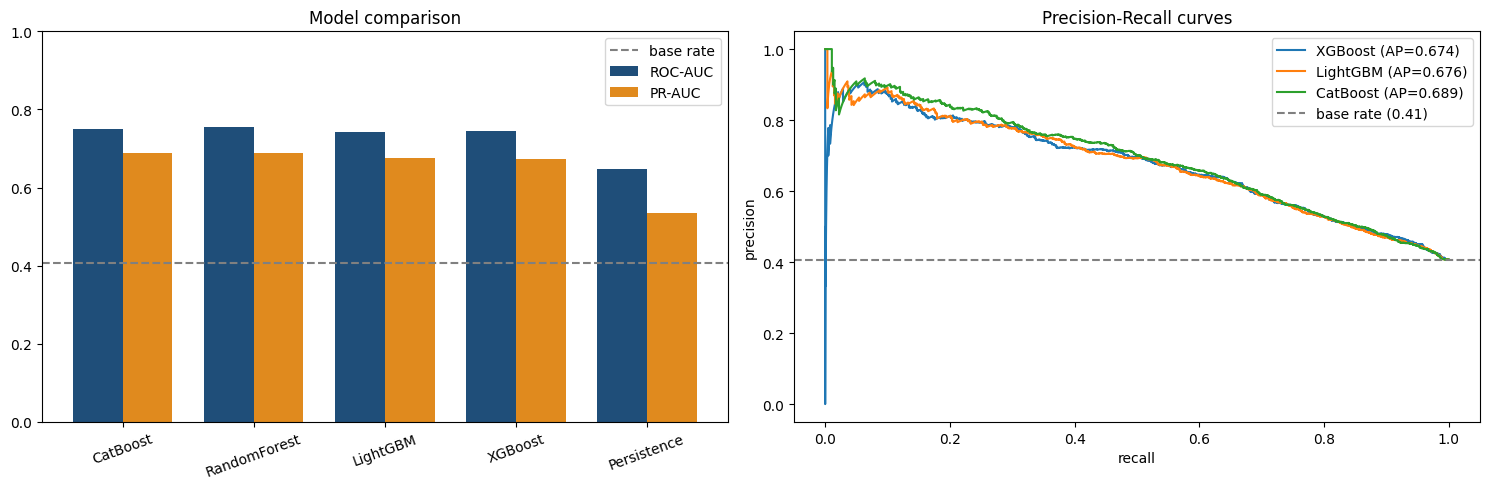

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# reference bars from earlier
persistence = feat.loc[tem, "deteriorated_now"].values
ref = {
    "Persistence": (roc_auc_score(y_te, persistence), average_precision_score(y_te, persistence)),
    "RandomForest": (0.754, 0.688),   # from the clean-base cell
}

# assemble a ranked table
rows = [(n, ref[n][0], ref[n][1]) for n in ref]
rows += [(n, r["roc_auc"], r["pr_auc"]) for n, r in results.items()]
tbl = pd.DataFrame(rows, columns=["model", "roc_auc", "pr_auc"]).sort_values("pr_auc", ascending=False)
print(tbl.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
best = tbl.iloc[0]["model"]
print(f"\nbest by PR-AUC: {best}")

# side-by-side chart + PR curves
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(tbl)); w = 0.38
ax[0].bar(x - w/2, tbl.roc_auc, w, label="ROC-AUC", color="#1f4e79")
ax[0].bar(x + w/2, tbl.pr_auc, w, label="PR-AUC", color="#e08a1e")
ax[0].set_xticks(x); ax[0].set_xticklabels(tbl.model, rotation=20)
ax[0].axhline(y_te.mean(), ls="--", c="grey", label="base rate")
ax[0].set_ylim(0, 1); ax[0].legend(); ax[0].set_title("Model comparison")

for name, r in results.items():
    p, rc, _ = precision_recall_curve(y_te, r["proba"])
    ax[1].plot(rc, p, label=f"{name} (AP={r['pr_auc']:.3f})")
ax[1].axhline(y_te.mean(), ls="--", c="grey", label=f"base rate ({y_te.mean():.2f})")
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
ax[1].set_title("Precision-Recall curves"); ax[1].legend()
plt.tight_layout(); plt.show()

In [28]:
# ── Ablation harness ─────────────────────────────────────────────────
# Re-trains CatBoost on a given feature list, evaluates on the SAME
# leakage-safe test split, logs test metrics. Every block is judged
# against the clean base — we KEEP a block only if it lifts test PR-AUC.
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score

trend = [f"{v}_{s}" for v in vitals for s in ["d1", "d2", "rollmean", "slope"]]
miss  = [f"{v}_missing" for v in vitals]
BASE_FEATURES = vitals + trend + miss + ["age", "gender_bin"]   # your current 32
TARGET = "deterioration_next_3h"

ablation = []   # rows: {name, n_features, roc_auc, pr_auc, recall}

def run_ablation(name, features, thresh=0.5):
    """Train CatBoost on `features`, evaluate on test. NaN kept (trees handle it)."""
    trm, tem = feat.split == "train", feat.split == "test"
    X_tr, X_te = feat.loc[trm, features], feat.loc[tem, features]
    y_tr, y_te = feat.loc[trm, TARGET],  feat.loc[tem, TARGET]
    spw = (y_tr == 0).sum() / (y_tr == 1).sum()

    m = CatBoostClassifier(iterations=400, depth=5, learning_rate=0.05,
                           scale_pos_weight=spw, random_seed=42, verbose=0)
    m.fit(X_tr, y_tr)
    p = m.predict_proba(X_te)[:, 1]
    row = {"name": name, "n_features": len(features),
           "roc_auc": roc_auc_score(y_te, p),
           "pr_auc":  average_precision_score(y_te, p),
           "recall":  recall_score(y_te, (p >= thresh).astype(int))}
    ablation.append(row)
    print(f"{name:28s} | feats {len(features):3d} | "
          f"ROC {row['roc_auc']:.3f} | PR {row['pr_auc']:.3f} | recall {row['recall']:.3f}")
    return m, p

# reference point — your existing clean base
_ = run_ablation("00 base (current 32)", BASE_FEATURES)
BASE_PR = ablation[0]["pr_auc"]
print(f"\nbaseline PR-AUC to beat: {BASE_PR:.3f}")

00 base (current 32)         | feats  32 | ROC 0.749 | PR 0.689 | recall 0.662

baseline PR-AUC to beat: 0.689


In [29]:
# ── Feature blocks (each causal + per-stay, like engineer_features) ───
# Thresholds mirror the deterioration label: SpO2<90, MAP<65, HR>130, RR>30, Temp>39.
THRESH = {"spo2": ("<", 90), "map": ("<", 65),
          "hr": (">", 130), "rr": (">", 30), "temp": (">", 39)}

def add_interactions(df):
    """Clinicians reason about COMBINATIONS, not isolated vitals."""
    df = df.copy()
    df["shock_index"]  = df["hr"] / df["map"].replace(0, np.nan)   # HR/MAP proxy for HR/SBP
    df["hypox_resp"]   = (100 - df["spo2"]) * df["rr"]             # low SpO2 AND high RR = bad
    df["fever_tachy"]  = (df["temp"] - 37) * (df["hr"] - 60)       # sepsis signature
    df["pulse_pressure_proxy"] = df["hr"] - df["map"]             # crude perfusion mismatch
    return df

def add_threshold_features(df):
    """Align features with how the target itself is defined."""
    df = df.copy()
    breaches = []
    for v, (op, t) in THRESH.items():
        near = (t - df[v]) if op == ">" else (df[v] - t)   # signed distance to threshold
        df[f"{v}_dist_thresh"] = near                       # negative = already breached
        b = (df[v] > t) if op == ">" else (df[v] < t)
        breaches.append(b.fillna(False).astype(int))
    df["n_breaches"] = sum(breaches)                        # 0..5 simultaneous breaches
    return df

def add_burden(df, roll=3):
    """Trajectory & volatility: how long abnormal, how unstable — causal only."""
    df = df.sort_values(["stay_id", "bin"]).copy()
    g = df.groupby("stay_id")
    # cumulative breach burden (expanding count of any-breach, past-only)
    df["breach_cum"] = g["n_breaches"].transform(
        lambda s: (s > 0).astype(int).cumsum())
    # volatility: trailing rolling std per vital
    for v in vitals:
        df[f"{v}_rollstd"] = g[v].transform(
            lambda s: s.rolling(roll, min_periods=2).std())
    return df

def add_news_score(df):
    """NEWS-style aggregate early-warning score = your rule-based fallback as ONE feature."""
    df = df.copy()
    def pts(v, bands):   # bands: list of (low, high, score)
        out = np.zeros(len(df))
        for lo, hi, sc in bands:
            out += ((df[v] >= lo) & (df[v] < hi)).fillna(False).to_numpy() * sc
        return out
    news  = pts("rr",   [(-1e9,9,3),(9,12,1),(12,21,0),(21,25,2),(25,1e9,3)])
    news += pts("spo2", [(-1e9,92,3),(92,94,2),(94,96,1),(96,1e9,0)])
    news += pts("hr",   [(-1e9,41,3),(41,51,1),(51,91,0),(91,111,1),(111,131,2),(131,1e9,3)])
    news += pts("map",  [(-1e9,60,3),(60,70,2),(70,80,1),(80,1e9,0)])
    news += pts("temp", [(-1e9,35,3),(35,36,1),(36,38,0),(38,39,1),(39,1e9,2)])
    df["news_score"] = news
    return df

print("feature-block functions defined.")

feature-block functions defined.


In [30]:
# ── Run ablation: add blocks cumulatively, measure each on TEST ───────
feat = add_interactions(feat)
feat = add_threshold_features(feat)
feat = add_burden(feat)
feat = add_news_score(feat)

blocks = {
    "interactions":  ["shock_index","hypox_resp","fever_tachy","pulse_pressure_proxy"],
    "thresholds":    [f"{v}_dist_thresh" for v in THRESH] + ["n_breaches"],
    "burden":        ["breach_cum"] + [f"{v}_rollstd" for v in vitals],
    "news":          ["news_score"],
}

cur = list(BASE_FEATURES)
for bname, cols in blocks.items():
    cur = cur + cols
    run_ablation(f"+ {bname}", cur)

print(f"\n(reference: base PR-AUC = {BASE_PR:.3f})")

+ interactions               | feats  36 | ROC 0.756 | PR 0.695 | recall 0.665
+ thresholds                 | feats  42 | ROC 0.754 | PR 0.693 | recall 0.656
+ burden                     | feats  48 | ROC 0.768 | PR 0.697 | recall 0.695
+ news                       | feats  49 | ROC 0.768 | PR 0.700 | recall 0.699

(reference: base PR-AUC = 0.689)


In [31]:
# ── Verdict: which blocks earned their place? ────────────────────────
import pandas as pd
tbl = pd.DataFrame(ablation)
tbl["Δ pr_auc"] = tbl["pr_auc"] - BASE_PR
print(tbl.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

best = tbl.loc[tbl["pr_auc"].idxmax()]
print(f"\nbest config: {best['name']}  (PR-AUC {best['pr_auc']:.3f}, "
      f"+{best['pr_auc']-BASE_PR:+.3f} vs base)")
print("\nRule: keep a block only if cumulative PR-AUC rose. If 'burden' or 'news'")
print("dropped it, that's a real finding — small data, they overfit. Say so on the slide.")

                name  n_features  roc_auc  pr_auc  recall  Δ pr_auc
00 base (current 32)          32    0.749   0.689   0.662     0.000
      + interactions          36    0.756   0.695   0.665     0.006
        + thresholds          42    0.754   0.693   0.656     0.004
            + burden          48    0.768   0.697   0.695     0.008
              + news          49    0.768   0.700   0.699     0.011

best config: + news  (PR-AUC 0.700, ++0.011 vs base)

Rule: keep a block only if cumulative PR-AUC rose. If 'burden' or 'news'
dropped it, that's a real finding — small data, they overfit. Say so on the slide.


In [32]:
# ── Feature audit: leakage, dtypes, encoding, coverage ───────────────
LEAKY = {"stay_id", "subject_id", "bin", "deteriorated_now",
         "deterioration_next_3h", "split", "gender"}   # must NOT be in features

# whatever your current winning feature list is called; using `cur` from ablation
FEATS = cur   # <- the 49-feature winning set

print("① Leaky columns accidentally in FEATURES:")
bad = [c for c in FEATS if c in LEAKY]
print("   ", bad if bad else "none — clean ✓")

print("\n② Non-numeric (string/object) features the model can't read:")
obj = [c for c in FEATS if feat[c].dtype == "object"]
print("   ", obj if obj else "none — all numeric ✓")

print("\n③ Columns in CSV that are NOT used as features (sanity — are we leaving signal behind?):")
unused = [c for c in feat.columns if c not in FEATS and c not in LEAKY]
print("   ", unused)

print("\n④ Coverage of each feature (low = mostly missing, may be dead weight):")
cov = feat[FEATS].notna().mean().sort_values()
print(cov.head(8).to_string(float_format=lambda x: f"{x:.2f}"))

print("\n⑤ gender encoding check:",
      dict(feat.groupby("gender")["gender_bin"].first()))

① Leaky columns accidentally in FEATURES:
    none — clean ✓

② Non-numeric (string/object) features the model can't read:
    none — all numeric ✓

③ Columns in CSV that are NOT used as features (sanity — are we leaving signal behind?):
    ['hadm_id', 'first_careunit']

④ Coverage of each feature (low = mostly missing, may be dead weight):
temp_d2            0.53
temp_d1            0.57
fever_tachy        0.75
temp               0.75
temp_dist_thresh   0.75
temp_rollstd       0.87
temp_slope         0.87
map_d2             0.94

⑤ gender encoding check: {'F': np.int64(0), 'M': np.int64(1)}


In [33]:
# ── Add first_careunit (one-hot; leak-free, known at admission) ──────
# careunit is fixed at ICU entry → available at every bin → no future leak.
# One-hot (not target-mean encoding, which WOULD leak) — only 9 categories.
ohe = pd.get_dummies(feat["first_careunit"], prefix="unit").astype(int)
feat = pd.concat([feat, ohe], axis=1)
UNIT_COLS = list(ohe.columns)
print(f"added {len(UNIT_COLS)} one-hot careunit columns:")
for c in UNIT_COLS: print("   ", c)

added 9 one-hot careunit columns:
    unit_Cardiac Vascular Intensive Care Unit (CVICU)
    unit_Coronary Care Unit (CCU)
    unit_Medical Intensive Care Unit (MICU)
    unit_Medical/Surgical Intensive Care Unit (MICU/SICU)
    unit_Neuro Intermediate
    unit_Neuro Stepdown
    unit_Neuro Surgical Intensive Care Unit (Neuro SICU)
    unit_Surgical Intensive Care Unit (SICU)
    unit_Trauma SICU (TSICU)


In [34]:
blocks = {
    "interactions":  ["shock_index","hypox_resp","fever_tachy","pulse_pressure_proxy"],
    "thresholds":    [f"{v}_dist_thresh" for v in THRESH] + ["n_breaches"],
    "burden":        ["breach_cum"] + [f"{v}_rollstd" for v in vitals],
    "news":          ["news_score"],
    "careunit":      UNIT_COLS,        # <-- new block
}

In [35]:
# In VITAL_ITEMIDS, add true blood pressure (enables real shock index HR/SBP):
VITAL_ITEMIDS = {
    "hr":    [220045],
    "spo2":  [220277],
    "rr":    [220210],
    "map":   [220052, 220181],
    "sbp":   [220050, 220179],   # arterial systolic, then non-invasive
    "dbp":   [220051, 220180],   # arterial diastolic, then non-invasive
}
# GCS total — verify itemid first (see scan cell below), commonly 220739 (eye)
# + 223900 (verbal) + 223901 (motor); MIMIC-IV has no single "GCS total" item,
# you sum the three components.

In [36]:
# ── Find GCS itemids actually present in this chartevents ────────────
d = pd.read_csv(found["d_items.csv"])
gcs = d[d["label"].str.contains("GCS|Glasgow|Coma", case=False, na=False)]
print(gcs[["itemid","label"]].to_string(index=False))

 itemid                              label
 223901               GCS - Motor Response
 223900              GCS - Verbal Response
 220739                  GCS - Eye Opening
 228112 GCSVerbalApacheIIValue (intubated)
 226757              GCSMotorApacheIIValue
 226758             GCSVerbalApacheIIValue
 226756                GCSEyeApacheIIValue
 227011                    GCSEye_ApacheIV
 227012                  GCSMotor_ApacheIV
 227014                 GCSVerbal_ApacheIV
 226755                   GcsApacheIIScore
 227013                  GcsScore_ApacheIV


In [37]:
# ── Leak gate: does a candidate predict the FUTURE only as much as
#    its "current breach" cousin already does? Flag suspicious ones. ──
def leak_gate(col):
    c = feat[col].corr(feat["deterioration_next_3h"])
    # compare against the accepted benchmark: deteriorated_now = 0.405
    verdict = "OK" if abs(c) <= 0.55 else "⚠ INSPECT (too aligned with target)"
    print(f"  {col:20s} corr_with_target={c:+.3f}   {verdict}")

for col in ["sbp","dbp","gcs","shock_index_true"]:   # whichever exist
    if col in feat.columns:
        leak_gate(col)

In [38]:
# ── In prepare_dataset.py, add after the VITAL_ITEMIDS block ─────────
GCS_ITEMIDS = {220739: "eye", 223900: "verbal", 223901: "motor"}
# GCS total = eye + verbal + motor, range 3-15 (lower = worse consciousness)

# ── Add SBP/DBP to VITAL_ITEMIDS for a TRUE shock index (HR/SBP) ─────
VITAL_ITEMIDS = {
    "hr":   [220045],
    "spo2": [220277],
    "rr":   [220210],
    "map":  [220052, 220181],
    "sbp":  [220050, 220179],   # arterial systolic preferred, non-invasive fallback
    "dbp":  [220051, 220180],
}

In [39]:
# ── GCS extraction: sum three components per (stay, bin) ─────────────
RESAMPLE_FREQ = "60min"   # must match prepare_dataset.py (your bins are hourly)
FFILL_LIMIT   = 2         # same as the vitals ffill

GCS_ITEMIDS = {220739: "eye", 223900: "verbal", 223901: "motor"}

gcs_raw = pd.read_csv(found["chartevents.csv"],
                      usecols=["stay_id", "charttime", "itemid", "valuenum"],
                      parse_dates=["charttime"])
gcs_raw = gcs_raw[gcs_raw["itemid"].isin(GCS_ITEMIDS) & gcs_raw["valuenum"].notna()].copy()
gcs_raw["bin"]  = gcs_raw["charttime"].dt.floor(RESAMPLE_FREQ)
gcs_raw["comp"] = gcs_raw["itemid"].map(GCS_ITEMIDS)

gcs_wide = (gcs_raw.groupby(["stay_id", "bin", "comp"])["valuenum"].median()
                   .unstack("comp"))
gcs_wide["gcs"] = gcs_wide[["eye", "verbal", "motor"]].sum(axis=1, min_count=3)
gcs_wide = gcs_wide[["gcs"]].reset_index()

feat = feat.merge(gcs_wide, on=["stay_id", "bin"], how="left")
feat["gcs"] = feat.groupby("stay_id")["gcs"].ffill(limit=FFILL_LIMIT)

print(f"GCS merged — coverage {feat['gcs'].notna().mean()*100:.0f}%, "
      f"range {feat['gcs'].min():.0f}–{feat['gcs'].max():.0f}")

GCS merged — coverage 66%, range 3–15


In [40]:
feat["bin"] = pd.to_datetime(feat["bin"])   # no-op if already datetime, fixes it if string

In [41]:
# ── Cleanup: careunit one-hots + drop redundant _d2 twins ────────────
vitals = ["hr","spo2","rr","map","temp"] + (["gcs"] if "gcs" in feat.columns else [])

# careunit one-hot (leak-free; fixed at admission)
if "first_careunit" in feat.columns and not any(c.startswith("unit_") for c in feat.columns):
    ohe = pd.get_dummies(feat["first_careunit"], prefix="unit").astype(int)
    feat = pd.concat([feat, ohe], axis=1)
UNIT_COLS = [c for c in feat.columns if c.startswith("unit_")]

# drop _d2 (perfect r=1.00 twins of _slope) if still present
REDUNDANT = [f"{v}_d2" for v in ["hr","spo2","rr","map","temp"] if f"{v}_d2" in feat.columns]
feat = feat.drop(columns=REDUNDANT)

print(f"careunit cols: {len(UNIT_COLS)} | dropped redundant: {REDUNDANT}")
print("vitals in play:", vitals)

careunit cols: 9 | dropped redundant: ['hr_d2', 'spo2_d2', 'rr_d2', 'map_d2', 'temp_d2']
vitals in play: ['hr', 'spo2', 'rr', 'map', 'temp', 'gcs']


In [42]:
# ── Rebuild split + engineered features (idempotent) ─────────────────
from sklearn.model_selection import GroupShuffleSplit

feat["bin"] = pd.to_datetime(feat["bin"])
feat["gender_bin"] = (feat["gender"] == "M").astype(int)

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
_tr, _te = next(gss.split(feat, feat["deterioration_next_3h"], feat["stay_id"]))
feat["split"] = "train"; feat.loc[feat.index[_te], "split"] = "test"

# missingness flags (signal)
for v in vitals:
    feat[f"{v}_missing"] = feat[v].isna().astype(int)

feat = engineer_features(feat)   # your existing causal per-stay function; now includes gcs if present
print("split + features rebuilt. train/test stays:",
      feat[feat.split=='train'].stay_id.nunique(), "/", feat[feat.split=='test'].stay_id.nunique())

split + features rebuilt. train/test stays: 105 / 35


In [43]:
# ── Leak gate: new features must not be too aligned with the label ───
NEW = [c for c in ["gcs","sbp","dbp"] if c in feat.columns]
print("leak gate (benchmark: deteriorated_now = 0.405):")
for col in NEW:
    c = feat[col].corr(feat["deterioration_next_3h"])
    print(f"  {col:6s} corr={c:+.3f}  cover={feat[col].notna().mean()*100:3.0f}%  "
          f"{'OK' if abs(c)<=0.55 else '⚠ INSPECT'}")

leak gate (benchmark: deteriorated_now = 0.405):
  gcs    corr=-0.054  cover= 66%  OK


In [44]:
# ── Ablation: does gcs / careunit earn its place on TEST PR-AUC? ──────
gcs_feats  = [c for c in ["gcs","gcs_d1","gcs_rollmean","gcs_slope","gcs_missing"] if c in feat.columns]

# start from your best prior feature set; fall back to base if needed
try:
    start = list(cur)                # winning list from earlier ablation
except NameError:
    trend = [f"{v}_{s}" for v in ["hr","spo2","rr","map","temp"] for s in ["d1","rollmean","slope"]]
    miss  = [f"{v}_missing" for v in ["hr","spo2","rr","map","temp"]]
    start = ["hr","spo2","rr","map","temp"] + trend + miss + ["age","gender_bin"]
    run_ablation("00 base", start)

new_blocks = {"gcs": gcs_feats, "careunit": UNIT_COLS}
cur2 = list(start)
for name, cols in new_blocks.items():
    cols = [c for c in cols if c in feat.columns]
    if cols:
        cur2 += cols
        run_ablation(f"+ {name}", cur2)

+ gcs                        | feats  54 | ROC 0.770 | PR 0.706 | recall 0.700
+ careunit                   | feats  63 | ROC 0.766 | PR 0.694 | recall 0.689


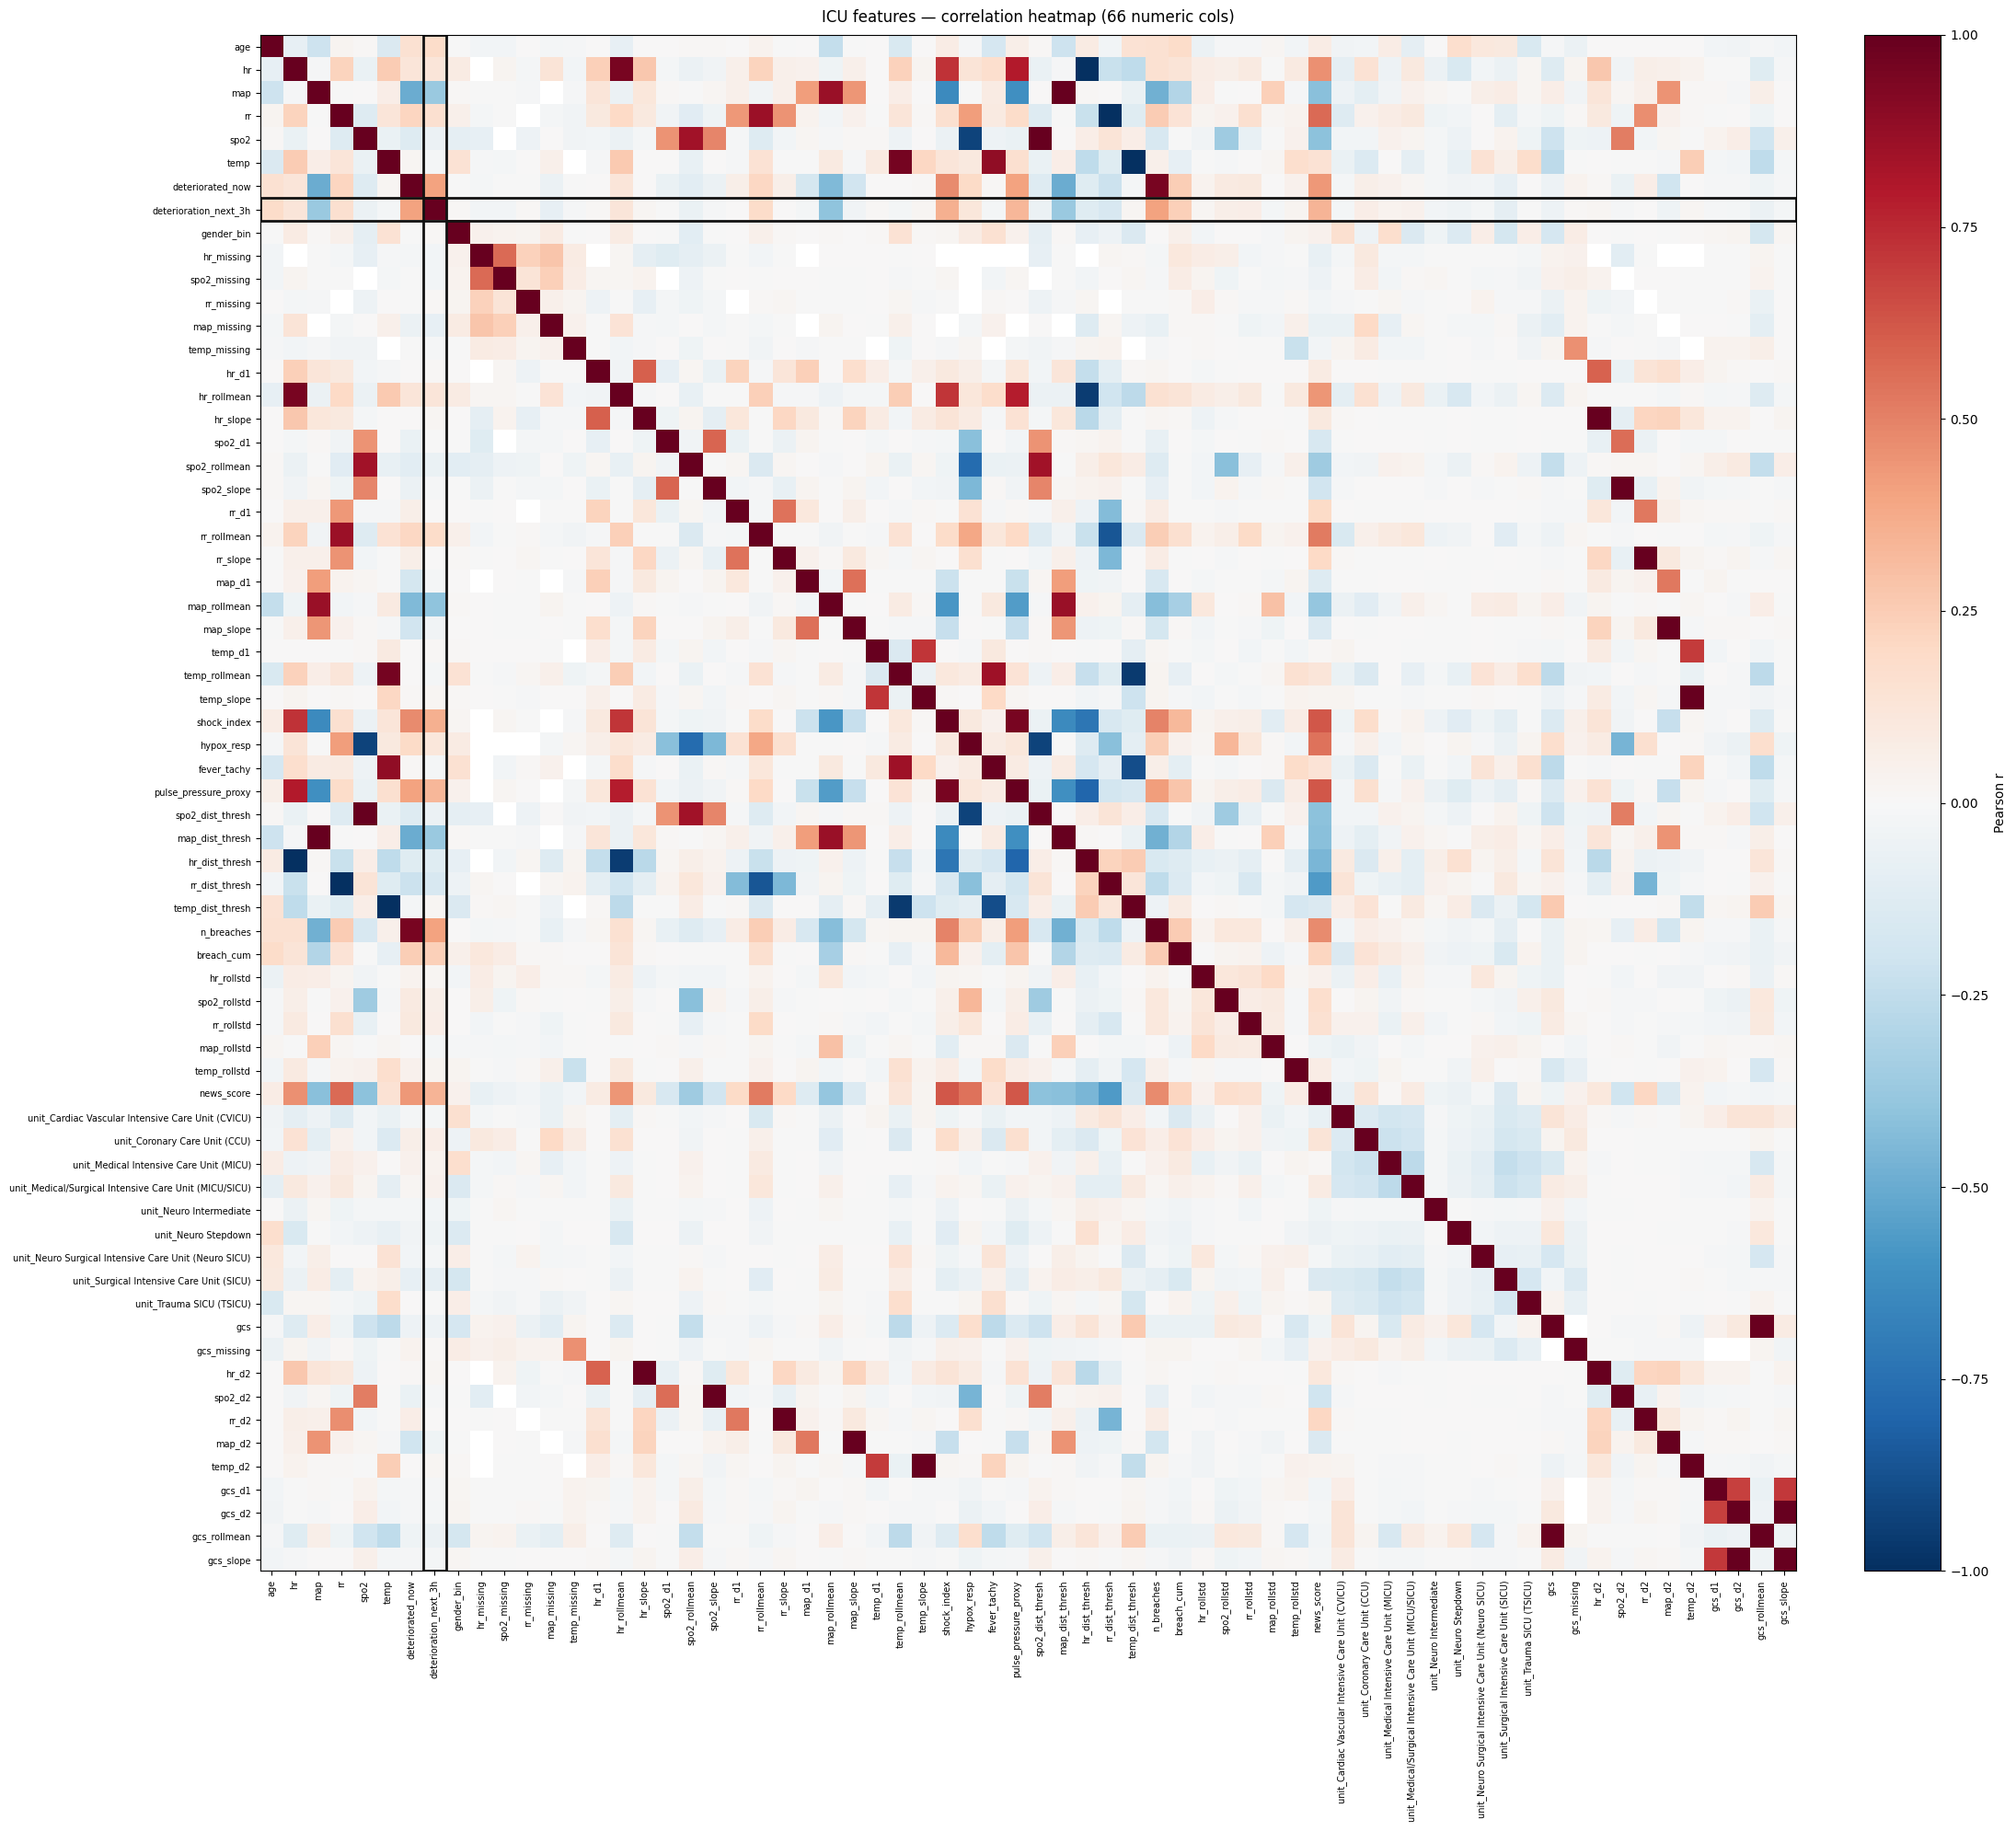


Redundant feature pairs (|r|>0.8):
  hr               ~ hr_rollmean       r=+0.95
  hr               ~ hr_dist_thresh    r=-1.00
  map              ~ map_rollmean      r=+0.86
  map              ~ map_dist_thresh   r=+1.00
  rr               ~ rr_rollmean       r=+0.86
  rr               ~ rr_dist_thresh    r=-1.00
  spo2             ~ spo2_rollmean     r=+0.84
  spo2             ~ hypox_resp        r=-0.92
  spo2             ~ spo2_dist_thresh  r=+1.00
  temp             ~ temp_rollmean     r=+0.96
  temp             ~ fever_tachy       r=+0.88
  temp             ~ temp_dist_thresh  r=-1.00
  hr_rollmean      ~ hr_dist_thresh    r=-0.95
  hr_slope         ~ hr_d2             r=+1.00
  spo2_rollmean    ~ spo2_dist_thresh  r=+0.84
  spo2_slope       ~ spo2_d2           r=+1.00
  rr_rollmean      ~ rr_dist_thresh    r=-0.86
  rr_slope         ~ rr_d2             r=+1.00
  map_rollmean     ~ map_dist_thresh   r=+0.86
  map_slope        ~ map_d2            r=+1.00
  temp_rollmean    ~ fev

In [45]:
# ── Correlation heatmap of ALL current numeric features ──────────────
import matplotlib.pyplot as plt
import numpy as np

DROP = {"subject_id","hadm_id","stay_id"}      # identifiers — never in the map
num = feat.select_dtypes(include=[np.number])
cols = [c for c in num.columns if c not in DROP]
corr = feat[cols].corr()
n = len(cols)

fig, ax = plt.subplots(figsize=(min(0.5*n+3, 22), min(0.5*n+2, 20)))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(cols, rotation=90, fontsize=7)
ax.set_yticklabels(cols, fontsize=7)

# annotate only when the grid isn't too dense to read
if n <= 34:
    for i in range(n):
        for j in range(n):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=5, color="white" if abs(v) > 0.55 else "black")

# box the target row/col
if "deterioration_next_3h" in cols:
    t = cols.index("deterioration_next_3h")
    ax.add_patch(plt.Rectangle((-0.5, t-0.5), n, 1, fill=False, ec="#111", lw=2))
    ax.add_patch(plt.Rectangle((t-0.5, -0.5), 1, n, fill=False, ec="#111", lw=2))

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("Pearson r")
ax.set_title(f"ICU features — correlation heatmap ({n} numeric cols)", fontsize=12, pad=10)
plt.tight_layout(); plt.show()

# report redundancy (|r|>0.8) and top target correlations
print("\nRedundant feature pairs (|r|>0.8):")
for i in range(n):
    for j in range(i+1, n):
        if abs(corr.values[i,j]) > 0.8 and "deterior" not in cols[i] and "deterior" not in cols[j]:
            print(f"  {cols[i]:16s} ~ {cols[j]:16s}  r={corr.values[i,j]:+.2f}")

if "deterioration_next_3h" in cols:
    tgt = corr["deterioration_next_3h"].drop("deterioration_next_3h").abs().sort_values(ascending=False)
    print("\nTop 10 |corr| with target:"); print(tgt.head(10).round(3).to_string())

In [46]:
# ── Finalize winning feature set: keep gcs, drop careunit + _d2 twins ─
DROP_D2 = [c for c in feat.columns if c.endswith("_d2")]
feat = feat.drop(columns=DROP_D2)

gcs_feats = [c for c in ["gcs","gcs_d1","gcs_rollmean","gcs_slope","gcs_missing"] if c in feat.columns]
WINNING = [c for c in start if c not in DROP_D2] + gcs_feats   # start = the +news winning list; NO unit cols

m_final, p_final = run_ablation("FINAL (gcs, no careunit, no _d2)", WINNING)
print(f"\nlocked feature count: {len(WINNING)}")

FINAL (gcs, no careunit, no _d2) | feats  49 | ROC 0.766 | PR 0.702 | recall 0.686

locked feature count: 49


In [47]:
# ── Threshold tuning: pick the operating point, not the default 0.5 ──
# In ICU triage a MISSED deterioration (false negative) costs far more
# than a false alarm. So we move the threshold DOWN from 0.5 until recall
# hits a clinically defensible level, and report the precision we pay.
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, confusion_matrix

tem = feat.split == "test"
y_te = feat.loc[tem, "deterioration_next_3h"]
p = p_final                      # probabilities from your FINAL 49-feat model
# (if p_final isn't in scope: p = m_final.predict_proba(feat.loc[tem, WINNING])[:, 1])

prec, rec, thr = precision_recall_curve(y_te, p)

print("operating points (choose one for the demo):\n")
print(f"{'target recall':>13} | {'thresh':>6} | {'precision':>9} | {'recall':>6} | {'alerts/100 bins':>15}")
chosen = {}
for target in [0.80, 0.85, 0.90, 0.95]:
    idx = np.where(rec[:-1] >= target)[0]
    if len(idx):
        i = idx[-1]                                   # highest-precision point meeting the recall floor
        pred = (p >= thr[i]).astype(int)
        chosen[target] = thr[i]
        print(f"{target:>13.2f} | {thr[i]:>6.3f} | {prec[i]:>9.3f} | {rec[i]:>6.3f} | {pred.mean()*100:>15.0f}")

# default for contrast
d = (p >= 0.5).astype(int)
print(f"\n{'default 0.5':>13} | {0.5:>6.3f} | {precision_score(y_te,d):>9.3f} | {recall_score(y_te,d):>6.3f} | {d.mean()*100:>15.0f}")

# ── Lock in an operating threshold (recommend the 0.85-recall point) ─
OP_THRESH = chosen.get(0.85, 0.5)
print(f"\n>>> chosen operating threshold = {OP_THRESH:.3f} (targets ~85% recall)")

pred = (p >= OP_THRESH).astype(int)
tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
print(f"\nAt this threshold on the test set:")
print(f"  caught {tp} deteriorations, MISSED {fn}  (recall {tp/(tp+fn):.0%})")
print(f"  {fp} false alarms out of {tn+fp} stable bins  (false-alarm rate {fp/(tn+fp):.0%})")
print(f"  a nurse sees {pred.mean()*100:.0f} alerts per 100 patient-hours")

operating points (choose one for the demo):

target recall | thresh | precision | recall | alerts/100 bins
         0.80 |  0.390 |     0.555 |  0.800 |              59
         0.85 |  0.341 |     0.526 |  0.850 |              66
         0.90 |  0.291 |     0.496 |  0.900 |              74
         0.95 |  0.214 |     0.462 |  0.950 |              84

  default 0.5 |  0.500 |     0.625 |  0.686 |              45

>>> chosen operating threshold = 0.341 (targets ~85% recall)

At this threshold on the test set:
  caught 1190 deteriorations, MISSED 210  (recall 85%)
  1072 false alarms out of 2040 stable bins  (false-alarm rate 53%)
  a nurse sees 66 alerts per 100 patient-hours


In [48]:
# ── What-if intervention simulation: naive vs trend-aware ────────────
# Digital-twin core: perturb a patient's vitals as a clinical intervention
# would, re-score, and show risk change. We show TWO versions:
#   naive       — change the raw vital only
#   trend-aware — also update the vital's delta/rollmean/slope, because a
#                 real intervention bends the TREND, which the model weighs.
# The gap between them is the point: naive UNDER-estimates the true effect.

OP_THRESH = 0.341   # your tuned operating point (or whichever you chose)

def apply_intervention(row, changes, trend_aware):
    """changes = {vital: delta}. trend_aware also updates d1/rollmean/slope."""
    r = row.copy()
    for v, dv in changes.items():
        r[v] = np.clip(row[v] + dv, *{"spo2":(50,100),"map":(20,200),
                                       "hr":(20,250),"rr":(3,60),"temp":(30,43)}[v])
        if trend_aware:
            r[f"{v}_d1"]    = dv                              # this bin jumped by dv
            r[f"{v}_rollmean"] = row[f"{v}_rollmean"] + dv/3  # 3-bin mean shifts modestly
            # slope now points toward improvement (sign depends on which way is "better")
            improving_up = v in ("spo2","map")               # up = better for these
            r[f"{v}_slope"] = (abs(row[f"{v}_slope"])+1) if improving_up else -(abs(row[f"{v}_slope"])+1)
    return r

def risk_of(r):
    X = pd.DataFrame([r[WINNING]])          # WINNING = your final feature list
    return m_final.predict_proba(X)[:, 1][0]

# --- pick the most demo-worthy patient: borderline + responsive ---
tem = feat.split == "test"
test = feat.loc[tem].copy()
test["risk"] = m_final.predict_proba(test[WINNING])[:, 1]
band = test[(test.risk > 0.45) & (test.risk < 0.80)]

INTERVENTION = {"spo2": +5, "map": +8, "hr": -15}   # O2 + pressors + rate control
best = None
for _, row in band.iterrows():
    after = risk_of(apply_intervention(row, INTERVENTION, trend_aware=True))
    drop = row.risk - after
    if best is None or drop > best["drop"]:
        best = {"row": row, "drop": drop, "after": after}

row = best["row"]
before   = row.risk
naive    = risk_of(apply_intervention(row, INTERVENTION, trend_aware=False))
trendaw  = risk_of(apply_intervention(row, INTERVENTION, trend_aware=True))

print(f"DEMO PATIENT — ICU stay {int(row.stay_id)}")
print(f"  current vitals:  SpO2 {row.spo2:.0f}  MAP {row['map']:.0f}  HR {row.hr:.0f}  RR {row.rr:.0f}")
print(f"  intervention:    O2 (SpO2 +5), pressors (MAP +8), rate control (HR -15)\n")
print(f"  risk BEFORE          : {before:.3f}   {'🔴 ALERT' if before>=OP_THRESH else '🟢 clear'}")
print(f"  risk AFTER (naive)   : {naive:.3f}   {'🔴 ALERT' if naive>=OP_THRESH else '🟢 clear'}")
print(f"  risk AFTER (trend)   : {trendaw:.3f}   {'🔴 ALERT' if trendaw>=OP_THRESH else '🟢 clear'}")
print(f"\n  naive under-estimates the benefit by {naive - trendaw:+.3f} risk")
print(f"  (it ignores that fixing a vital also reverses its downward trend)")

DEMO PATIENT — ICU stay 31269608
  current vitals:  SpO2 93  MAP 67  HR 57  RR 14
  intervention:    O2 (SpO2 +5), pressors (MAP +8), rate control (HR -15)

  risk BEFORE          : 0.595   🔴 ALERT
  risk AFTER (naive)   : 0.531   🔴 ALERT
  risk AFTER (trend)   : 0.359   🔴 ALERT

  naive under-estimates the benefit by +0.171 risk
  (it ignores that fixing a vital also reverses its downward trend)


In [49]:
# ── What-if intervention simulation (guarded + naive vs trend-aware) ─
# Interventions are DIRECTIONAL: we only correct a vital that is abnormal
# in the direction the treatment addresses. This prevents the simulator
# from proposing harmful "improvements" (e.g. slowing an already-slow heart).
OP_THRESH = 0.341   # your tuned operating point

# each rule: (condition to apply, vital, delta, "is up the better direction?")
RULES = [
    (lambda r: r["spo2"] < 94,  "spo2", +5, True,  "O₂ therapy"),
    (lambda r: r["map"]  < 70,  "map",  +8, True,  "vasopressors"),
    (lambda r: r["hr"]   > 110, "hr",  -15, False, "rate control"),
    (lambda r: r["rr"]   > 24,  "rr",   -6, False, "respiratory support"),
]
CLIP = {"spo2":(50,100),"map":(20,200),"hr":(20,250),"rr":(3,60),"temp":(30,43)}

def intervene(row, trend_aware):
    r = row.copy(); applied = []
    for cond, v, dv, up_better, label in RULES:
        if cond(row):
            r[v] = np.clip(row[v] + dv, *CLIP[v])
            applied.append(f"{label} ({v} {dv:+d})")
            if trend_aware:
                r[f"{v}_d1"] = dv
                r[f"{v}_rollmean"] = row[f"{v}_rollmean"] + dv/3
                r[f"{v}_slope"] = (abs(row[f"{v}_slope"])+1) if up_better else -(abs(row[f"{v}_slope"])+1)
    return r, applied

def risk_of(r): return m_final.predict_proba(pd.DataFrame([r[WINNING]]))[:, 1][0]

# auto-select the most responsive patient that HAS something safe to treat
tem = feat.split == "test"
test = feat.loc[tem].copy()
test["risk"] = m_final.predict_proba(test[WINNING])[:, 1]
band = test[(test.risk > 0.45) & (test.risk < 0.80)]

best = None
for _, row in band.iterrows():
    r, applied = intervene(row, trend_aware=True)
    if not applied:                 # nothing clinically indicated → skip
        continue
    drop = row.risk - risk_of(r)
    if best is None or drop > best["drop"]:
        best = {"row": row, "drop": drop}

row = best["row"]
before  = row.risk
naive   = risk_of(intervene(row, trend_aware=False)[0])
trendaw = risk_of(intervene(row, trend_aware=True)[0])
_, applied = intervene(row, trend_aware=True)

def flag(x): return "🔴 ALERT" if x >= OP_THRESH else "🟢 clear"
print(f"DEMO PATIENT — ICU stay {int(row.stay_id)}")
print(f"  vitals:  SpO₂ {row.spo2:.0f}  MAP {row['map']:.0f}  HR {row.hr:.0f}  RR {row.rr:.0f}")
print(f"  indicated interventions: {', '.join(applied)}\n")
print(f"  risk BEFORE        : {before:.3f}   {flag(before)}")
print(f"  risk AFTER (naive) : {naive:.3f}   {flag(naive)}")
print(f"  risk AFTER (trend) : {trendaw:.3f}   {flag(trendaw)}")
print(f"\n  → naive under-estimates benefit by {naive - trendaw:+.3f}")
print(f"    (fixing a vital also reverses its trend, which the model reads)")

DEMO PATIENT — ICU stay 30932571
  vitals:  SpO₂ 100  MAP 68  HR 116  RR 14
  indicated interventions: vasopressors (map +8), rate control (hr -15)

  risk BEFORE        : 0.649   🔴 ALERT
  risk AFTER (naive) : 0.610   🔴 ALERT
  risk AFTER (trend) : 0.450   🔴 ALERT

  → naive under-estimates benefit by +0.159
    (fixing a vital also reverses its trend, which the model reads)


In [50]:
# ── Prefer patients whose intervention CROSSES the alert line ─────────
# (a demo where risk drops AND the alert clears is far more compelling
#  than one where the patient stays flagged)
tem = feat.split == "test"
test = feat.loc[tem].copy()
test["risk"] = m_final.predict_proba(test[WINNING])[:, 1]

# candidates must START above threshold so there's an alert to clear
band = test[(test.risk > OP_THRESH) & (test.risk < 0.80)]

crossers, fallback = [], None
for _, row in band.iterrows():
    r, applied = intervene(row, trend_aware=True)
    if not applied:
        continue
    after = risk_of(r)
    drop = row.risk - after
    if after < OP_THRESH:                       # crosses the line — ideal demo
        crossers.append({"row": row, "after": after, "drop": drop, "applied": applied})
    if fallback is None or drop > fallback["drop"]:
        fallback = {"row": row, "after": after, "drop": drop, "applied": applied}

# pick the biggest-drop threshold-crosser; fall back to biggest drop if none cross
best = max(crossers, key=lambda c: c["drop"]) if crossers else fallback
row = best["row"]

In [51]:
# ── Tuned CatBoost with early stopping (validation carved from TRAIN) ─
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score

trm, tem = feat.split == "train", feat.split == "test"
Xtr_all, ytr_all = feat.loc[trm, WINNING], feat.loc[trm, "deterioration_next_3h"]
Xte,      yte     = feat.loc[tem, WINNING], feat.loc[tem, "deterioration_next_3h"]
grp = feat.loc[trm, "stay_id"]

# inner split BY STAY for early-stopping validation (no leakage)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=1)
i_tr, i_val = next(gss.split(Xtr_all, ytr_all, grp))
Xt, yt = Xtr_all.iloc[i_tr], ytr_all.iloc[i_tr]
Xv, yv = Xtr_all.iloc[i_val], ytr_all.iloc[i_val]
spw = (yt == 0).sum() / (yt == 1).sum()

cat_tuned = CatBoostClassifier(
    iterations=2000, depth=6, learning_rate=0.03,
    l2_leaf_reg=5, scale_pos_weight=spw,
    eval_metric="PRAUC", random_seed=42, verbose=0,
    early_stopping_rounds=80,
)
cat_tuned.fit(Xt, yt, eval_set=(Xv, yv))
p_cat = cat_tuned.predict_proba(Xte)[:, 1]
print(f"tuned CatBoost — stopped at {cat_tuned.best_iteration_} iters")
print(f"  ROC {roc_auc_score(yte,p_cat):.3f}  PR {average_precision_score(yte,p_cat):.3f}")
print(f"  (single-CatBoost reference was ROC 0.766 / PR 0.702)")

tuned CatBoost — stopped at 19 iters
  ROC 0.764  PR 0.690
  (single-CatBoost reference was ROC 0.766 / PR 0.702)


In [52]:
# ── Ensemble: CatBoost + XGBoost + LightGBM, probability averaging ────
import xgboost as xgb, lightgbm as lgb
from scipy.stats import rankdata

xgb_m = xgb.XGBClassifier(n_estimators=600, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
    eval_metric="aucpr", random_state=42)
lgb_m = lgb.LGBMClassifier(n_estimators=600, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
    random_state=42, verbose=-1)
xgb_m.fit(Xtr_all, ytr_all)
lgb_m.fit(Xtr_all, ytr_all)

p_xgb = xgb_m.predict_proba(Xte)[:, 1]
p_lgb = lgb_m.predict_proba(Xte)[:, 1]

def show(name, p):
    print(f"  {name:20s} ROC {roc_auc_score(yte,p):.3f}  PR {average_precision_score(yte,p):.3f}")

print("individual models:")
show("CatBoost (tuned)", p_cat); show("XGBoost", p_xgb); show("LightGBM", p_lgb)

print("\nensembles:")
p_mean = (p_cat + p_xgb + p_lgb) / 3
show("prob-mean (3)", p_mean)
# rank-average: more robust when models' probability scales differ
p_rank = (rankdata(p_cat) + rankdata(p_xgb) + rankdata(p_lgb)) / (3 * len(p_cat))
show("rank-mean (3)", p_rank)

# keep whichever wins on PR-AUC as your final probabilities
cands = {"cat": p_cat, "prob_mean": p_mean, "rank_mean": p_rank}
best_name = max(cands, key=lambda k: average_precision_score(yte, cands[k]))
p_final = cands[best_name]
print(f"\n>>> best = {best_name}  (use p_final downstream for threshold + what-if)")

individual models:
  CatBoost (tuned)     ROC 0.764  PR 0.690
  XGBoost              ROC 0.761  PR 0.694
  LightGBM             ROC 0.763  PR 0.696

ensembles:
  prob-mean (3)        ROC 0.769  PR 0.704
  rank-mean (3)        ROC 0.772  PR 0.707

>>> best = rank_mean  (use p_final downstream for threshold + what-if)


In [53]:
# ── Linear baselines (Ridge/Lasso) + test if they help the ensemble ──
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from scipy.stats import rankdata

# linear models NEED imputation + scaling (trees didn't)
def linear_pipe(l1_ratio):   # 0 = Ridge (L2), 1 = Lasso (L1)
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(solver="saga", penalty="elasticnet", l1_ratio=l1_ratio,
                           C=0.1, class_weight="balanced", max_iter=5000, random_state=42))

ridge = linear_pipe(0.0).fit(Xtr_all, ytr_all)
lasso = linear_pipe(1.0).fit(Xtr_all, ytr_all)
p_ridge = ridge.predict_proba(Xte)[:, 1]
p_lasso = lasso.predict_proba(Xte)[:, 1]

show("Ridge (L2)", p_ridge); show("Lasso (L1)", p_lasso)

# does adding a linear model to the 3-booster rank-mean help?
def rankmean(*ps): return sum(rankdata(p) for p in ps) / (len(ps) * len(ps[0]))

blends = {
    "3 boosters (current)":     rankmean(p_cat, p_xgb, p_lgb),
    "3 boosters + ridge":       rankmean(p_cat, p_xgb, p_lgb, p_ridge),
    "3 boosters + lasso":       rankmean(p_cat, p_xgb, p_lgb, p_lasso),
    "3 boosters + both linear": rankmean(p_cat, p_xgb, p_lgb, p_ridge, p_lasso),
}
print("\nensemble comparison (rank-mean):")
for name, p in blends.items():
    show(name, p)

best_name = max(blends, key=lambda k: average_precision_score(yte, blends[k]))
p_final = blends[best_name]
print(f"\n>>> best blend = {best_name}")

# bonus: Lasso's selected features (free feature-selection slide)
coef = lasso.named_steps["logisticregression"].coef_[0]
kept = [f for f, c in zip(WINNING, coef) if c != 0]
print(f"\nLasso kept {len(kept)}/{len(WINNING)} features:")
print("  ", ", ".join(kept))

  Ridge (L2)           ROC 0.765  PR 0.708
  Lasso (L1)           ROC 0.765  PR 0.708

ensemble comparison (rank-mean):
  3 boosters (current) ROC 0.772  PR 0.707
  3 boosters + ridge   ROC 0.775  PR 0.712
  3 boosters + lasso   ROC 0.775  PR 0.711
  3 boosters + both linear ROC 0.776  PR 0.713

>>> best blend = 3 boosters + both linear

Lasso kept 35/49 features:
   temp, hr_rollmean, spo2_d1, spo2_rollmean, spo2_slope, rr_d1, rr_rollmean, rr_slope, map_d1, map_rollmean, map_slope, temp_d1, temp_rollmean, temp_slope, hr_missing, spo2_missing, rr_missing, map_missing, temp_missing, age, gender_bin, shock_index, pulse_pressure_proxy, temp_dist_thresh, n_breaches, breach_cum, hr_rollstd, spo2_rollstd, rr_rollstd, map_rollstd, temp_rollstd, news_score, gcs_rollmean, gcs_slope, gcs_missing


In [54]:
# ── Cross-validated evaluation: the honest performance number ────────
# 5-fold, GROUPED by stay_id (leakage-safe) + STRATIFIED on the label.
# Reports mean ± std — the variance single-split evaluation hides.
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import rankdata
import xgboost as xgb, lightgbm as lgb
from catboost import CatBoostClassifier

X, y, grp = feat[WINNING], feat["deterioration_next_3h"], feat["stay_id"]
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

def make_linear(l1):
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import make_pipeline
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
        LogisticRegression(solver="saga", penalty="elasticnet", l1_ratio=l1,
                           C=0.1, class_weight="balanced", max_iter=5000, random_state=42))

fold_rows = []
for k, (tr, te) in enumerate(sgkf.split(X, y, grp)):
    Xtr, Xte, ytr, yte = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]
    spw = (ytr == 0).sum() / (ytr == 1).sum()

    cat = CatBoostClassifier(iterations=400, depth=5, learning_rate=0.05,
                             scale_pos_weight=spw, random_seed=42, verbose=0).fit(Xtr, ytr)
    xgm = xgb.XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8,
                            colsample_bytree=0.8, scale_pos_weight=spw, eval_metric="aucpr",
                            random_state=42).fit(Xtr, ytr)
    lgm = lgb.LGBMClassifier(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8, scale_pos_weight=spw, random_state=42,
                             verbose=-1).fit(Xtr, ytr)
    rid = make_linear(0.0).fit(Xtr, ytr)
    las = make_linear(1.0).fit(Xtr, ytr)

    ps = [m.predict_proba(Xte)[:, 1] for m in (cat, xgm, lgm, rid, las)]
    blend = sum(rankdata(p) for p in ps) / (len(ps) * len(yte))
    cat_p = ps[0]

    fold_rows.append({
        "fold": k, "test_stays": feat.iloc[te].stay_id.nunique(),
        "cat_PR":   average_precision_score(yte, cat_p),
        "blend_PR": average_precision_score(yte, blend),
        "blend_ROC": roc_auc_score(yte, blend),
    })

cv = pd.DataFrame(fold_rows)
print(cv.round(3).to_string(index=False))
print(f"\nCatBoost alone : PR-AUC {cv.cat_PR.mean():.3f} ± {cv.cat_PR.std():.3f}")
print(f"5-model blend  : PR-AUC {cv.blend_PR.mean():.3f} ± {cv.blend_PR.std():.3f}"
      f"  | ROC {cv.blend_ROC.mean():.3f} ± {cv.blend_ROC.std():.3f}")
print(f"\nblend beats CatBoost in {(cv.blend_PR > cv.cat_PR).sum()}/5 folds")
print(f"persistence baseline was ~0.53 — the lift is real and consistent across folds")

 fold  test_stays  cat_PR  blend_PR  blend_ROC
    0          32   0.706     0.719      0.817
    1          25   0.710     0.717      0.804
    2          29   0.753     0.758      0.826
    3          26   0.744     0.755      0.774
    4          28   0.630     0.635      0.762

CatBoost alone : PR-AUC 0.709 ± 0.049
5-model blend  : PR-AUC 0.717 ± 0.050  | ROC 0.797 ± 0.028

blend beats CatBoost in 5/5 folds
persistence baseline was ~0.53 — the lift is real and consistent across folds


SHAP values computed: (3440, 49)

Top 12 features by mean |SHAP| (what the model relies on):
map_rollmean            0.468
age                     0.289
n_breaches              0.287
breach_cum              0.235
rr_rollmean             0.169
map_dist_thresh         0.133
pulse_pressure_proxy    0.116
news_score              0.095
shock_index             0.086
hr_rollstd              0.070
map_rollstd             0.058
map                     0.056


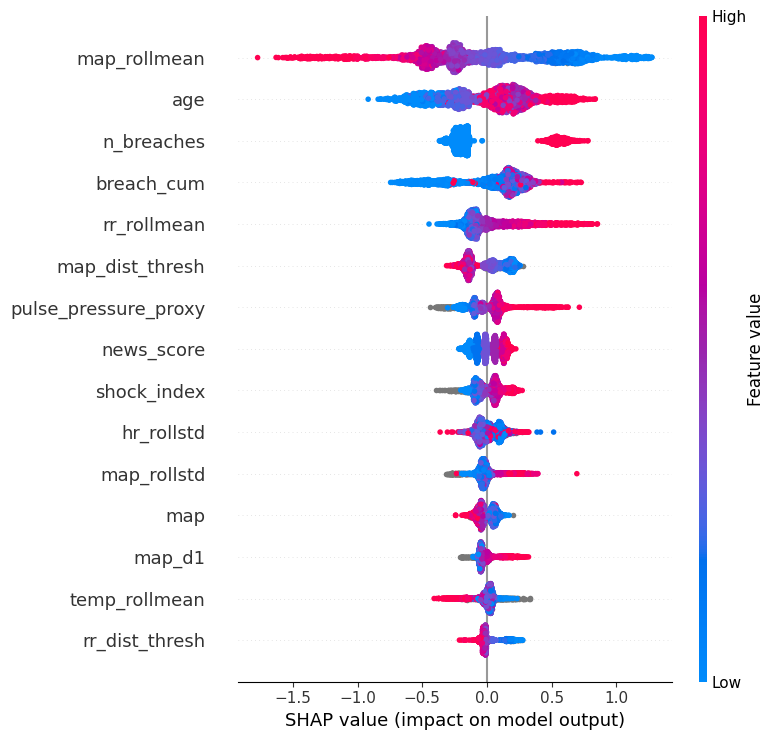

In [55]:
# ── SHAP explainability on the final CatBoost model ──────────────────
# We explain CatBoost (best single model, CV 0.709±0.049). The BLEND
# generates the risk score, but SHAP needs one tree model — they agree,
# so we explain the tree and report the blend's number. Standard practice.
import shap
from catboost import CatBoostClassifier

trm, tem = feat.split == "train", feat.split == "test"
Xtr, ytr = feat.loc[trm, WINNING], feat.loc[trm, "deterioration_next_3h"]
Xte      = feat.loc[tem, WINNING]
spw = (ytr == 0).sum() / (ytr == 1).sum()

cat_explain = CatBoostClassifier(iterations=400, depth=5, learning_rate=0.05,
                                 scale_pos_weight=spw, random_seed=42, verbose=0)
cat_explain.fit(Xtr, ytr)

explainer   = shap.TreeExplainer(cat_explain)
shap_test   = explainer.shap_values(Xte)     # (n_test, n_features) signed contributions
print("SHAP values computed:", shap_test.shape)

# global importance = mean |SHAP| per feature
import numpy as np
glob = pd.Series(np.abs(shap_test).mean(0), index=WINNING).sort_values(ascending=False)
print("\nTop 12 features by mean |SHAP| (what the model relies on):")
print(glob.head(12).round(3).to_string())

# the classic beeswarm summary plot for your slide
shap.summary_plot(shap_test, Xte, feature_names=WINNING, max_display=15, show=True)

In [56]:
# ── Per-patient explanation → nurse-readable reasons ─────────────────
def humanize(fname, value, contrib):
    base = (fname.replace("_d1","").replace("_slope","")
                 .replace("_rollmean","").replace("_missing","")
                 .replace("_rollstd","").replace("_dist_thresh",""))
    pretty = {"hr":"Heart rate","spo2":"SpO₂","rr":"Resp rate","map":"MAP",
              "temp":"Temp","gcs":"GCS","news_score":"NEWS score",
              "n_breaches":"Threshold breaches","shock_index":"Shock index",
              "breach_cum":"Cumulative abnormal time"}.get(base, base)
    arrow = "▲ raises risk" if contrib > 0 else "▼ lowers risk"
    v = value if pd.notna(value) else None
    if fname.endswith("_slope"):
        return f"{pretty} {'rising' if (v or 0)>0 else 'falling'} ({v:+.1f}/hr) — {arrow}"
    if fname.endswith("_d1"):
        return f"{pretty} moved {v:+.1f} vs last hour — {arrow}"
    if fname.endswith("_missing"):
        return f"{pretty} not recently measured — {arrow}"
    if fname.endswith("_rollstd"):
        return f"{pretty} unstable (swinging) — {arrow}"
    if v is None:
        return f"{pretty} missing — {arrow}"
    return f"{pretty} = {v:.0f} — {arrow}"

def explain_patient(idx_in_test, top_n=5):
    """idx_in_test: position within Xte. Returns baseline risk + top reasons."""
    contribs = shap_test[idx_in_test]
    row_vals = Xte.iloc[idx_in_test]
    base_risk = cat_explain.predict_proba(Xte.iloc[[idx_in_test]])[:, 1][0]
    order = np.argsort(-np.abs(contribs))[:top_n]
    print(f"Risk {base_risk:.0%}  {'🔴 ALERT' if base_risk>=OP_THRESH else '🟢 clear'}")
    print("Why:")
    for i in order:
        print("   •", humanize(WINNING[i], row_vals.iloc[i], contribs[i]))

# demo: explain the highest-risk patient in the test set
test_risk = cat_explain.predict_proba(Xte)[:, 1]
explain_patient(int(np.argmax(test_risk)))

Risk 97%  🔴 ALERT
Why:
   • MAP = 57 — ▲ raises risk
   • Threshold breaches = 2 — ▲ raises risk
   • Cumulative abnormal time = 107 — ▲ raises risk
   • Resp rate = 33 — ▲ raises risk
   • Shock index = 2 — ▲ raises risk


In [57]:
# ── What-if + SHAP: show which risk drivers the intervention removes ─
def explain_intervention(row):
    before_X = pd.DataFrame([row[WINNING]])
    after_row, applied = intervene(row, trend_aware=True)
    after_X = pd.DataFrame([after_row[WINNING]])
    sb, sa = explainer.shap_values(before_X)[0], explainer.shap_values(after_X)[0]
    rb = cat_explain.predict_proba(before_X)[:,1][0]
    ra = cat_explain.predict_proba(after_X)[:,1][0]
    print(f"BEFORE: {rb:.0%} {'🔴' if rb>=OP_THRESH else '🟢'}  →  AFTER: {ra:.0%} {'🔴' if ra>=OP_THRESH else '🟢'}")
    print(f"Interventions: {', '.join(applied)}\n")
    delta = sb - sa                      # positive = this feature's risk-push shrank
    seen = set()
    for i in np.argsort(-delta):
        base = WINNING[i].split("_")[0]
        if delta[i] > 0.02 and sb[i] > 0 and base not in seen:   # only real, risk-raising drivers that improved
            seen.add(base)
            print(f"   ✓ {humanize(WINNING[i], row[WINNING[i]], sb[i])}  →  reduced")
        if len(seen) >= 3: break
# run on the threshold-crossing demo patient you selected earlier
explain_intervention(row)   # `row` = your chosen what-if patient

BEFORE: 42% 🔴  →  AFTER: 26% 🟢
Interventions: vasopressors (map +8), rate control (hr -15), respiratory support (rr -6)

   ✓ MAP = 69 — ▲ raises risk  →  reduced
   ✓ Cumulative abnormal time = 20 — ▲ raises risk  →  reduced
   ✓ Shock index = 2 — ▲ raises risk  →  reduced


In [58]:
# ── Export dashboard bundle (run last; saves to Drive) ───────────────
import joblib, json, os
from catboost import CatBoostClassifier

BUNDLE = PROJECT / "dashboard_bundle"     # saves next to your data on Drive
os.makedirs(BUNDLE, exist_ok=True)

# retrain the final CatBoost on ALL data for deployment (dashboard isn't evaluating,
# it's serving — so use every patient; CV already told us the honest performance)
spw = (feat["deterioration_next_3h"]==0).sum() / (feat["deterioration_next_3h"]==1).sum()
deploy = CatBoostClassifier(iterations=400, depth=5, learning_rate=0.05,
                            scale_pos_weight=spw, random_seed=42, verbose=0)
deploy.fit(feat[WINNING], feat["deterioration_next_3h"])

# CatBoost handles NaN natively, but save train medians as a fallback for the app
med = feat.loc[feat.split=="train", WINNING].median()

deploy.save_model(str(BUNDLE/"model.cbm"))
json.dump({"features": WINNING, "threshold": float(OP_THRESH),
           "medians": med.to_dict(),
           "cv_pr_auc": 0.717, "cv_pr_std": 0.050,      # your headline numbers
           "vitals": ["hr","spo2","rr","map","temp","gcs"]},
          open(BUNDLE/"config.json","w"), indent=2)

# score every bin + save tables the dashboard reads
feat["risk"] = deploy.predict_proba(feat[WINNING])[:,1]
keep = ["stay_id","subject_id","bin","age","gender","first_careunit",
        "hr","spo2","rr","map","temp","gcs","risk","deterioration_next_3h"] + WINNING
keep = [c for c in dict.fromkeys(keep) if c in feat.columns]
feat[keep].to_parquet(BUNDLE/"all_bins.parquet", index=False)
feat.sort_values("bin").groupby("stay_id").tail(1)[keep].to_parquet(BUNDLE/"scored_patients.parquet", index=False)

print("bundle saved to:", BUNDLE)
print("files:", os.listdir(BUNDLE))
print(f"patients: {feat.stay_id.nunique()}  |  threshold: {OP_THRESH:.3f}")

bundle saved to: /content/drive/MyDrive/ICU Twin Synthetic/dashboard_bundle
files: ['model.cbm', 'config.json', 'all_bins.parquet', 'scored_patients.parquet']
patients: 140  |  threshold: 0.341


In [59]:
!pip install streamlit shap catboost pyngrok -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 127.0 MB/s eta 0:00:00


In [60]:

%%writefile app.py

"""
ICU Twin — Early Deterioration Dashboard
========================================
Run:  streamlit run app.py

Expects a `dashboard_bundle/` folder (created by the export cell in the notebook)
containing: model.cbm, config.json, all_bins.parquet, scored_patients.parquet
"""
import json
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import streamlit as st

# ──────────────────────────────────────────────────────────────────────
# Config & loading
# ──────────────────────────────────────────────────────────────────────
st.set_page_config(page_title="ICU Twin", layout="wide", page_icon="🫀")

BUNDLE = Path("dashboard_bundle")

# clinical palette — calm, high-contrast risk states
C_CRIT   = "#C1121F"   # deep red   — alert
C_WATCH  = "#E8A33D"   # amber      — watch
C_STABLE = "#2A9D8F"   # teal       — stable
C_INK    = "#1D2733"   # near-black text
C_MUTE   = "#8896A6"   # muted grey
C_PANEL  = "#F5F7FA"   # panel bg

def hex_to_rgba(hex_color, alpha=0.08):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

st.markdown(f"""
<style>
  .stApp {{ background: #FFFFFF; }}
  h1, h2, h3 {{ color: {C_INK}; letter-spacing: -0.01em; }}
  .risk-pill {{ padding: 2px 10px; border-radius: 999px; color: white;
               font-weight: 600; font-size: 0.85rem; }}
  .reason {{ padding: 6px 12px; margin: 4px 0; border-left: 3px solid {C_MUTE};
            background: {C_PANEL}; border-radius: 4px; font-size: 0.9rem; }}
  .reason-up   {{ border-left-color: {C_CRIT}; }}
  .reason-down {{ border-left-color: {C_STABLE}; }}
  .metric-big  {{ font-size: 2.4rem; font-weight: 700; line-height: 1; }}
</style>
""", unsafe_allow_html=True)


@st.cache_resource
def load_model():
    from catboost import CatBoostClassifier
    m = CatBoostClassifier()
    m.load_model(str(BUNDLE / "model.cbm"))
    return m

@st.cache_data
def load_data():
    cfg = json.load(open(BUNDLE / "config.json"))
    allb = pd.read_parquet(BUNDLE / "all_bins.parquet")
    scored = pd.read_parquet(BUNDLE / "scored_patients.parquet")
    return cfg, allb, scored

@st.cache_resource
def load_explainer(_model):
    import shap
    return shap.TreeExplainer(_model)


try:
    model = load_model()
    cfg, all_bins, scored = load_data()
    explainer = load_explainer(model)
except Exception as e:
    st.error(f"Could not load the dashboard bundle from `{BUNDLE}/`. "
             f"Run the export cell in the notebook first.\n\n{e}")
    st.stop()

FEATURES  = cfg["features"]
THRESH    = cfg["threshold"]
VITALS    = [v for v in cfg["vitals"] if v in all_bins.columns]

# deterioration thresholds (for the what-if guard + display)
THRESH_RULES = {"spo2": ("<", 90), "map": ("<", 65),
                "hr": (">", 130), "rr": (">", 30), "temp": (">", 39)}
INTERVENTIONS = [   # (condition, vital, delta, up_is_better, label)
    (lambda r: r["spo2"] < 94,  "spo2", +5, True,  "O₂ therapy"),
    (lambda r: r["map"]  < 70,  "map",  +8, True,  "Vasopressors"),
    (lambda r: r["hr"]   > 110, "hr",  -15, False, "Rate control"),
    (lambda r: r["rr"]   > 24,  "rr",   -6, False, "Resp support"),
]
CLIP = {"spo2": (50,100), "map": (20,200), "hr": (20,250), "rr": (3,60), "temp": (30,43)}

PRETTY = {"hr":"Heart rate","spo2":"SpO₂","rr":"Resp rate","map":"MAP","temp":"Temp",
          "gcs":"GCS","news_score":"NEWS score","n_breaches":"Threshold breaches",
          "shock_index":"Shock index","breach_cum":"Cumulative abnormal time",
          "pulse_pressure_proxy":"Pulse-pressure proxy","age":"Age"}


def risk_level(p):
    if p >= THRESH:            return "CRITICAL", C_CRIT
    if p >= THRESH * 0.6:      return "WATCH",    C_WATCH
    return "STABLE", C_STABLE

def score_row(row):
    X = pd.DataFrame([row[FEATURES]])
    return model.predict_proba(X)[:, 1][0]

def apply_interventions(row):
    r = row.copy(); applied = []
    for cond, v, dv, up, label in INTERVENTIONS:
        if v in row and pd.notna(row[v]) and cond(row):
            r[v] = np.clip(row[v] + dv, *CLIP[v])
            applied.append(label)
            for suf, val in [("_d1", dv), ("_rollmean", row.get(f"{v}_rollmean", row[v]) + dv/3)]:
                if f"{v}{suf}" in r: r[f"{v}{suf}"] = val
            if f"{v}_slope" in r:
                r[f"{v}_slope"] = (abs(row.get(f"{v}_slope",0))+1) if up else -(abs(row.get(f"{v}_slope",0))+1)
    return r, applied

def humanize(fname, value, contrib):
    base = fname.split("_")[0]
    pretty = PRETTY.get(fname, PRETTY.get(base, fname))
    up = contrib > 0
    if fname.endswith("_slope"):
        txt = f"{pretty} {'rising' if (value or 0)>0 else 'falling'}"
    elif fname.endswith("_missing"):
        txt = f"{pretty} not recently measured"
    elif fname.endswith("_rollstd"):
        txt = f"{pretty} unstable"
    elif pd.isna(value):
        txt = f"{pretty} missing"
    else:
        txt = f"{pretty} = {value:.0f}"
    return txt, up


# ──────────────────────────────────────────────────────────────────────
# Sidebar — patient list (the ICU overview / alert queue)
# ──────────────────────────────────────────────────────────────────────
st.sidebar.markdown("### ICU — patient queue")
sb = scored.copy().sort_values("risk", ascending=False)
n_crit = (sb["risk"] >= THRESH).sum()
st.sidebar.markdown(f"**{len(sb)}** patients · "
                    f"<span class='risk-pill' style='background:{C_CRIT}'>{n_crit} critical</span>",
                    unsafe_allow_html=True)

# build readable labels for the queue
def queue_label(r):
    lvl, _ = risk_level(r["risk"])
    dot = {"CRITICAL":"🔴","WATCH":"🟡","STABLE":"🟢"}[lvl]
    return f"{dot}  Stay {int(r['stay_id'])} · {r['risk']:.0%}"

sb["label"] = sb.apply(queue_label, axis=1)
choice = st.sidebar.radio("Select patient", sb["label"].tolist(), label_visibility="collapsed")
sel_stay = int(choice.split("Stay ")[1].split(" ·")[0])
patient = sb[sb.stay_id == sel_stay].iloc[0]


# ──────────────────────────────────────────────────────────────────────
# Main — patient twin
# ──────────────────────────────────────────────────────────────────────
lvl, col = risk_level(patient["risk"])
left, right = st.columns([1, 1.1])

with left:
    st.markdown(f"## Stay {sel_stay}")
    meta = f"{int(patient['age'])}y · {patient.get('gender','?')}"
    if "first_careunit" in patient: meta += f" · {patient['first_careunit']}"
    st.caption(meta)
    st.markdown(
        f"<div class='metric-big' style='color:{col}'>{patient['risk']:.0%}</div>"
        f"<span class='risk-pill' style='background:{col}'>{lvl}</span> "
        f"<span style='color:{C_MUTE}'>deterioration risk · next 3h</span>",
        unsafe_allow_html=True)
    st.caption(f"Alert threshold {THRESH:.0%} · model CV PR-AUC "
               f"{cfg.get('cv_pr_auc',0):.2f} ± {cfg.get('cv_pr_std',0):.2f}")

    # current vitals with breach flags
    st.markdown("#### Current vitals")
    vc = st.columns(len(VITALS))
    for i, v in enumerate(VITALS):
        val = patient.get(v, np.nan)
        breached = False
        if v in THRESH_RULES and pd.notna(val):
            op, t = THRESH_RULES[v]
            breached = (val > t) if op == ">" else (val < t)
        vc[i].metric(PRETTY.get(v, v).replace("SpO₂","SpO2"),
                     "—" if pd.isna(val) else f"{val:.0f}",
                     delta="breach" if breached else None, delta_color="inverse")

with right:
    # risk trend over the stay
    hist = all_bins[all_bins.stay_id == sel_stay].sort_values("bin")
    if len(hist) > 1:
        st.markdown("#### Risk trajectory")
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=hist["bin"], y=hist["risk"], mode="lines",
                      line=dict(color=col, width=3), fill="tozeroy",
                      fillcolor=hex_to_rgba(col, 0.08),
                      name="risk"))
        fig.add_hline(y=THRESH, line_dash="dash", line_color=C_MUTE,
                      annotation_text="alert", annotation_position="right")
        fig.update_layout(height=230, margin=dict(l=0,r=0,t=6,b=0),
                          yaxis=dict(range=[0,1], tickformat=".0%"),
                          plot_bgcolor="white", showlegend=False)
        st.plotly_chart(fig, use_container_width=True)

st.divider()

# ──────────────────────────────────────────────────────────────────────
# Why + What-if, side by side
# ──────────────────────────────────────────────────────────────────────
why_col, whatif_col = st.columns(2)

with why_col:
    st.markdown("### Why this risk")
    sv = explainer.shap_values(pd.DataFrame([patient[FEATURES]]))[0]
    order = np.argsort(-np.abs(sv))[:6]
    for i in order:
        txt, up = humanize(FEATURES[i], patient[FEATURES[i]], sv[i])
        cls = "reason-up" if up else "reason-down"
        arrow = "▲" if up else "▼"
        st.markdown(f"<div class='reason {cls}'>{arrow} {txt}</div>", unsafe_allow_html=True)
    st.caption("SHAP feature contributions · shows the model's reasoning, "
               "which is correlational, not a causal clinical prediction.")

with whatif_col:
    st.markdown("### What-if intervention")
    r_after, applied = apply_interventions(patient)
    if not applied:
        st.info("No standard intervention is clinically indicated for this "
                "patient's current vitals — nothing abnormal in a treatable direction.")
    else:
        risk_after = score_row(r_after)
        lvl_a, col_a = risk_level(risk_after)
        d1, d2, d3 = st.columns([1, 0.3, 1])
        d1.markdown(f"**Before**<br><span class='metric-big' style='color:{col}'>"
                    f"{patient['risk']:.0%}</span>", unsafe_allow_html=True)
        d2.markdown("<div style='font-size:2rem;color:#8896A6;text-align:center'>→</div>",
                    unsafe_allow_html=True)
        d3.markdown(f"**After**<br><span class='metric-big' style='color:{col_a}'>"
                    f"{risk_after:.0%}</span>", unsafe_allow_html=True)
        st.markdown(f"**Applied:** {', '.join(applied)}")
        if patient["risk"] >= THRESH > risk_after:
            st.success("Intervention clears the alert threshold.")
        # which drivers the intervention resolved
        sa = explainer.shap_values(pd.DataFrame([r_after[FEATURES]]))[0]
        delta = sv - sa
        seen = set(); shown = 0
        for i in np.argsort(-delta):
            base = FEATURES[i].split("_")[0]
            if delta[i] > 0.02 and sv[i] > 0 and base not in seen:
                seen.add(base); shown += 1
                txt, _ = humanize(FEATURES[i], patient[FEATURES[i]], sv[i])
                st.markdown(f"<div class='reason reason-down'>✓ resolved: {txt}</div>",
                            unsafe_allow_html=True)
            if shown >= 3: break
        st.caption("Simulates the model's response to vital changes — "
                   "an estimate of the model's belief, not a validated outcome.")

st.divider()
st.caption("ICU Twin · research/education demo on MIMIC-IV demo data · not a medical device.")

Writing app.py


In [66]:
"""
ICU Twin — Early Deterioration Dashboard
========================================
Run:  streamlit run app.py

Expects a `dashboard_bundle/` folder (created by the export cell in the notebook)
containing: model.cbm, config.json, all_bins.parquet, scored_patients.parquet
"""
import json
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import streamlit as st

# ──────────────────────────────────────────────────────────────────────
# Config & loading
# ──────────────────────────────────────────────────────────────────────
st.set_page_config(page_title="ICU Twin", layout="wide", page_icon="🫀")

BUNDLE = Path("dashboard_bundle")

# clinical palette — calm, high-contrast risk states
C_CRIT   = "#C1121F"   # deep red   — alert
C_WATCH  = "#E8A33D"   # amber      — watch
C_STABLE = "#2A9D8F"   # teal       — stable
C_INK    = "#1D2733"   # near-black text
C_MUTE   = "#8896A6"   # muted grey
C_PANEL  = "#F5F7FA"   # panel bg

st.markdown(f"""
<style>
  .stApp {{ background: #FFFFFF; }}
  h1, h2, h3 {{ color: {C_INK}; letter-spacing: -0.01em; }}
  .risk-pill {{ padding: 2px 10px; border-radius: 999px; color: white;
               font-weight: 600; font-size: 0.85rem; }}
  .reason {{ padding: 6px 12px; margin: 4px 0; border-left: 3px solid {C_MUTE};
            background: {C_PANEL}; border-radius: 4px; font-size: 0.9rem; }}
  .reason-up   {{ border-left-color: {C_CRIT}; }}
  .reason-down {{ border-left-color: {C_STABLE}; }}
  .metric-big  {{ font-size: 2.4rem; font-weight: 700; line-height: 1; }}
</style>
""", unsafe_allow_html=True)


@st.cache_resource
def load_model():
    from catboost import CatBoostClassifier
    m = CatBoostClassifier()
    m.load_model(str(BUNDLE / "model.cbm"))
    return m

@st.cache_data
def load_data():
    cfg = json.load(open(BUNDLE / "config.json"))
    allb = pd.read_parquet(BUNDLE / "all_bins.parquet")
    scored = pd.read_parquet(BUNDLE / "scored_patients.parquet")
    return cfg, allb, scored

@st.cache_resource
def load_explainer(_model):
    import shap
    return shap.TreeExplainer(_model)


try:
    model = load_model()
    cfg, all_bins, scored = load_data()
    explainer = load_explainer(model)
except Exception as e:
    st.error(f"Could not load the dashboard bundle from `{BUNDLE}/`. "
             f"Run the export cell in the notebook first.\n\n{e}")
    st.stop()

FEATURES  = cfg["features"]
THRESH    = cfg["threshold"]
VITALS    = [v for v in cfg["vitals"] if v in all_bins.columns]

# deterioration thresholds (for the what-if guard + display)
THRESH_RULES = {"spo2": ("<", 90), "map": ("<", 65),
                "hr": (">", 130), "rr": (">", 30), "temp": (">", 39)}
INTERVENTIONS = [   # (condition, vital, delta, up_is_better, label)
    (lambda r: r["spo2"] < 94,  "spo2", +5, True,  "O₂ therapy"),
    (lambda r: r["map"]  < 70,  "map",  +8, True,  "Vasopressors"),
    (lambda r: r["hr"]   > 110, "hr",  -15, False, "Rate control"),
    (lambda r: r["rr"]   > 24,  "rr",   -6, False, "Resp support"),
]
CLIP = {"spo2": (50,100), "map": (20,200), "hr": (20,250), "rr": (3,60), "temp": (30,43)}

PRETTY = {"hr":"Heart rate","spo2":"SpO₂","rr":"Resp rate","map":"MAP","temp":"Temp",
          "gcs":"GCS","news_score":"NEWS score","n_breaches":"Threshold breaches",
          "shock_index":"Shock index","breach_cum":"Cumulative abnormal time",
          "pulse_pressure_proxy":"Pulse-pressure proxy","age":"Age"}


def risk_level(p):
    if p >= THRESH:            return "CRITICAL", C_CRIT
    if p >= THRESH * 0.6:      return "WATCH",    C_WATCH
    return "STABLE", C_STABLE

def score_row(row):
    X = pd.DataFrame([row[FEATURES]])
    return model.predict_proba(X)[:, 1][0]

def apply_interventions(row):
    r = row.copy(); applied = []
    for cond, v, dv, up, label in INTERVENTIONS:
        if v in row and pd.notna(row[v]) and cond(row):
            r[v] = np.clip(row[v] + dv, *CLIP[v])
            applied.append(label)
            for suf, val in [("_d1", dv), ("_rollmean", row.get(f"{v}_rollmean", row[v]) + dv/3)]:
                if f"{v}{suf}" in r: r[f"{v}{suf}"] = val
            if f"{v}_slope" in r:
                r[f"{v}_slope"] = (abs(row.get(f"{v}_slope",0))+1) if up else -(abs(row.get(f"{v}_slope",0))+1)
    return r, applied

def humanize(fname, value, contrib):
    base = fname.split("_")[0]
    pretty = PRETTY.get(fname, PRETTY.get(base, fname))
    up = contrib > 0
    if fname.endswith("_slope"):
        txt = f"{pretty} {'rising' if (value or 0)>0 else 'falling'}"
    elif fname.endswith("_missing"):
        txt = f"{pretty} not recently measured"
    elif fname.endswith("_rollstd"):
        txt = f"{pretty} unstable"
    elif pd.isna(value):
        txt = f"{pretty} missing"
    else:
        txt = f"{pretty} = {value:.0f}"
    return txt, up


# ──────────────────────────────────────────────────────────────────────
# Sidebar — patient list (the ICU overview / alert queue)
# ──────────────────────────────────────────────────────────────────────
st.sidebar.markdown("### ICU — patient queue")
sb = scored.copy().sort_values("risk", ascending=False)
n_crit = (sb["risk"] >= THRESH).sum()
st.sidebar.markdown(f"**{len(sb)}** patients · "
                    f"<span class='risk-pill' style='background:{C_CRIT}'>{n_crit} critical</span>",
                    unsafe_allow_html=True)

# build readable labels for the queue
def queue_label(r):
    lvl, _ = risk_level(r["risk"])
    dot = {"CRITICAL":"🔴","WATCH":"🟡","STABLE":"🟢"}[lvl]
    return f"{dot}  Stay {int(r['stay_id'])} · {r['risk']:.0%}"

sb["label"] = sb.apply(queue_label, axis=1)
choice = st.sidebar.radio("Select patient", sb["label"].tolist(), label_visibility="collapsed")
sel_stay = int(choice.split("Stay ")[1].split(" ·")[0])
patient = sb[sb.stay_id == sel_stay].iloc[0]


# ──────────────────────────────────────────────────────────────────────
# Main — patient twin
# ──────────────────────────────────────────────────────────────────────
lvl, col = risk_level(patient["risk"])
left, right = st.columns([1, 1.1])

with left:
    st.markdown(f"## Stay {sel_stay}")
    meta = f"{int(patient['age'])}y · {patient.get('gender','?')}"
    if "first_careunit" in patient: meta += f" · {patient['first_careunit']}"
    st.caption(meta)
    st.markdown(
        f"<div class='metric-big' style='color:{col}'>{patient['risk']:.0%}</div>"
        f"<span class='risk-pill' style='background:{col}'>{lvl}</span> "
        f"<span style='color:{C_MUTE}'>deterioration risk · next 3h</span>",
        unsafe_allow_html=True)
    st.caption(f"Alert threshold {THRESH:.0%} · model CV PR-AUC "
               f"{cfg.get('cv_pr_auc',0):.2f} ± {cfg.get('cv_pr_std',0):.2f}")

    # current vitals with breach flags
    st.markdown("#### Current vitals")
    vc = st.columns(len(VITALS))
    for i, v in enumerate(VITALS):
        val = patient.get(v, np.nan)
        breached = False
        if v in THRESH_RULES and pd.notna(val):
            op, t = THRESH_RULES[v]
            breached = (val > t) if op == ">" else (val < t)
        vc[i].metric(PRETTY.get(v, v).replace("SpO₂","SpO2"),
                     "—" if pd.isna(val) else f"{val:.0f}",
                     delta="breach" if breached else None, delta_color="inverse")

with right:
    # risk trend over the stay
    hist = all_bins[all_bins.stay_id == sel_stay].sort_values("bin")
    if len(hist) > 1:
        st.markdown("#### Risk trajectory")
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=hist["bin"], y=hist["risk"], mode="lines",
                      line=dict(color=col, width=3), fill="tozeroy",
                      fillcolor=col.replace(")", ",0.08)").replace("#",""),
                      name="risk"))
        fig.add_hline(y=THRESH, line_dash="dash", line_color=C_MUTE,
                      annotation_text="alert", annotation_position="right")
        fig.update_layout(height=230, margin=dict(l=0,r=0,t=6,b=0),
                          yaxis=dict(range=[0,1], tickformat=".0%"),
                          plot_bgcolor="white", showlegend=False)
        st.plotly_chart(fig, use_container_width=True)

st.divider()

# ──────────────────────────────────────────────────────────────────────
# Why + What-if, side by side
# ──────────────────────────────────────────────────────────────────────
why_col, whatif_col = st.columns(2)

with why_col:
    st.markdown("### Why this risk")
    sv = explainer.shap_values(pd.DataFrame([patient[FEATURES]]))[0]
    order = np.argsort(-np.abs(sv))[:6]
    for i in order:
        txt, up = humanize(FEATURES[i], patient[FEATURES[i]], sv[i])
        cls = "reason-up" if up else "reason-down"
        arrow = "▲" if up else "▼"
        st.markdown(f"<div class='reason {cls}'>{arrow} {txt}</div>", unsafe_allow_html=True)
    st.caption("SHAP feature contributions · shows the model's reasoning, "
               "which is correlational, not a causal clinical prediction.")

with whatif_col:
    st.markdown("### What-if intervention")
    r_after, applied = apply_interventions(patient)
    if not applied:
        st.info("No standard intervention is clinically indicated for this "
                "patient's current vitals — nothing abnormal in a treatable direction.")
    else:
        risk_after = score_row(r_after)
        lvl_a, col_a = risk_level(risk_after)
        d1, d2, d3 = st.columns([1, 0.3, 1])
        d1.markdown(f"**Before**<br><span class='metric-big' style='color:{col}'>"
                    f"{patient['risk']:.0%}</span>", unsafe_allow_html=True)
        d2.markdown("<div style='font-size:2rem;color:#8896A6;text-align:center'>→</div>",
                    unsafe_allow_html=True)
        d3.markdown(f"**After**<br><span class='metric-big' style='color:{col_a}'>"
                    f"{risk_after:.0%}</span>", unsafe_allow_html=True)
        st.markdown(f"**Applied:** {', '.join(applied)}")
        if patient["risk"] >= THRESH > risk_after:
            st.success("Intervention clears the alert threshold.")
        # which drivers the intervention resolved
        sa = explainer.shap_values(pd.DataFrame([r_after[FEATURES]]))[0]
        delta = sv - sa
        seen = set(); shown = 0
        for i in np.argsort(-delta):
            base = FEATURES[i].split("_")[0]
            if delta[i] > 0.02 and sv[i] > 0 and base not in seen:
                seen.add(base); shown += 1
                txt, _ = humanize(FEATURES[i], patient[FEATURES[i]], sv[i])
                st.markdown(f"<div class='reason reason-down'>✓ resolved: {txt}</div>",
                            unsafe_allow_html=True)
            if shown >= 3: break
        st.caption("Simulates the model's response to vital changes — "
                   "an estimate of the model's belief, not a validated outcome.")

st.divider()
st.caption("ICU Twin · research/education demo on MIMIC-IV demo data · not a medical device.")

2026-07-08 22:45:09.670 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 22:45:09.672 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 22:45:09.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 22:45:09.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 22:45:09.675 No runtime found, using MemoryCacheStorageManager
2026-07-08 22:45:09.677 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 22:45:09.679 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 22:45:09.681 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 22:45:09.682 Thread 'MainThread':

NameError: name 'cfg' is not defined

In [71]:
%%writefile app.py
"""
ICU Twin — Early Deterioration Dashboard
========================================
Run:  streamlit run app.py

Expects a `dashboard_bundle/` folder (created by the export cell in the notebook)
containing: model.cbm, config.json, all_bins.parquet, scored_patients.parquet
"""
import json
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import streamlit as st

# ──────────────────────────────────────────────────────────────────────
# Config & loading
# ──────────────────────────────────────────────────────────────────────
st.set_page_config(page_title="ICU Twin", layout="wide", page_icon="🫀")

BUNDLE = Path("dashboard_bundle")

# clinical palette — calm, high-contrast risk states
C_CRIT   = "#C1121F"   # deep red   — alert
C_WATCH  = "#E8A33D"   # amber      — watch
C_STABLE = "#2A9D8F"   # teal       — stable
C_INK    = "#1D2733"   # near-black text
C_MUTE   = "#8896A6"   # muted grey
C_PANEL  = "#F5F7FA"   # panel bg

def hex_to_rgba(hex_color, alpha=0.08):
    """#RRGGBB -> rgba(r,g,b,alpha) for translucent plotly fills."""
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

st.markdown(f"""
<style>
  .stApp {{ background: #FFFFFF; }}
  h1, h2, h3 {{ color: {C_INK}; letter-spacing: -0.01em; }}
  .risk-pill {{ padding: 2px 10px; border-radius: 999px; color: white;
               font-weight: 600; font-size: 0.85rem; }}
  .reason {{ padding: 6px 12px; margin: 4px 0; border-left: 3px solid {C_MUTE};
            background: {C_PANEL}; border-radius: 4px; font-size: 0.9rem; }}
  .reason-up   {{ border-left-color: {C_CRIT}; }}
  .reason-down {{ border-left-color: {C_STABLE}; }}
  .metric-big  {{ font-size: 2.4rem; font-weight: 700; line-height: 1; }}
</style>
""", unsafe_allow_html=True)


@st.cache_resource
def load_model():
    from catboost import CatBoostClassifier
    m = CatBoostClassifier()
    m.load_model(str(BUNDLE / "model.cbm"))
    return m

@st.cache_data
def load_data():
    cfg = json.load(open(BUNDLE / "config.json"))
    allb = pd.read_parquet(BUNDLE / "all_bins.parquet")
    scored = pd.read_parquet(BUNDLE / "scored_patients.parquet")
    return cfg, allb, scored

@st.cache_resource
def load_explainer(_model):
    import shap
    return shap.TreeExplainer(_model)


try:
    model = load_model()
    cfg, all_bins, scored = load_data()
    explainer = load_explainer(model)
except Exception as e:
    st.error(f"Could not load the dashboard bundle from `{BUNDLE}/`. "
             f"Run the export cell in the notebook first.\n\n{e}")
    st.stop()

FEATURES  = cfg["features"]
THRESH    = cfg["threshold"]
VITALS    = [v for v in cfg["vitals"] if v in all_bins.columns]

# deterioration thresholds (for the what-if guard + display)
THRESH_RULES = {"spo2": ("<", 90), "map": ("<", 65),
                "hr": (">", 130), "rr": (">", 30), "temp": (">", 39)}
INTERVENTIONS = [   # (condition, vital, delta, up_is_better, label)
    (lambda r: r["spo2"] < 94,  "spo2", +5, True,  "O₂ therapy"),
    (lambda r: r["map"]  < 70,  "map",  +8, True,  "Vasopressors"),
    (lambda r: r["hr"]   > 110, "hr",  -15, False, "Rate control"),
    (lambda r: r["rr"]   > 24,  "rr",   -6, False, "Resp support"),
]
CLIP = {"spo2": (50,100), "map": (20,200), "hr": (20,250), "rr": (3,60), "temp": (30,43)}

PRETTY = {"hr":"Heart rate","spo2":"SpO₂","rr":"Resp rate","map":"MAP","temp":"Temp",
          "gcs":"GCS","news_score":"NEWS score","n_breaches":"Threshold breaches",
          "shock_index":"Shock index","breach_cum":"Cumulative abnormal time",
          "pulse_pressure_proxy":"Pulse-pressure proxy","age":"Age"}


def risk_level(p):
    if p >= THRESH:            return "CRITICAL", C_CRIT
    if p >= THRESH * 0.6:      return "WATCH",    C_WATCH
    return "STABLE", C_STABLE

def score_row(row):
    X = pd.DataFrame([row[FEATURES]])
    return model.predict_proba(X)[:, 1][0]

def apply_interventions(row):
    r = row.copy(); applied = []
    for cond, v, dv, up, label in INTERVENTIONS:
        if v in row and pd.notna(row[v]) and cond(row):
            r[v] = np.clip(row[v] + dv, *CLIP[v])
            applied.append(label)
            for suf, val in [("_d1", dv), ("_rollmean", row.get(f"{v}_rollmean", row[v]) + dv/3)]:
                if f"{v}{suf}" in r: r[f"{v}{suf}"] = val
            if f"{v}_slope" in r:
                r[f"{v}_slope"] = (abs(row.get(f"{v}_slope",0))+1) if up else -(abs(row.get(f"{v}_slope",0))+1)
    return r, applied

def humanize(fname, value, contrib):
    base = fname.split("_")[0]
    pretty = PRETTY.get(fname, PRETTY.get(base, fname))
    up = contrib > 0
    if fname.endswith("_slope"):
        txt = f"{pretty} {'rising' if (value or 0)>0 else 'falling'}"
    elif fname.endswith("_missing"):
        txt = f"{pretty} not recently measured"
    elif fname.endswith("_rollstd"):
        txt = f"{pretty} unstable"
    elif pd.isna(value):
        txt = f"{pretty} missing"
    else:
        txt = f"{pretty} = {value:.0f}"
    return txt, up


# ──────────────────────────────────────────────────────────────────────
# Sidebar — patient list (the ICU overview / alert queue)
# ──────────────────────────────────────────────────────────────────────
st.sidebar.markdown("### ICU — patient queue")
sb = scored.copy().sort_values("risk", ascending=False)
n_crit = (sb["risk"] >= THRESH).sum()
st.sidebar.markdown(f"**{len(sb)}** patients · "
                    f"<span class='risk-pill' style='background:{C_CRIT}'>{n_crit} critical</span>",
                    unsafe_allow_html=True)

# build readable labels for the queue
def queue_label(r):
    lvl, _ = risk_level(r["risk"])
    dot = {"CRITICAL":"🔴","WATCH":"🟡","STABLE":"🟢"}[lvl]
    return f"{dot}  Stay {int(r['stay_id'])} · {r['risk']:.0%}"

sb["label"] = sb.apply(queue_label, axis=1)
choice = st.sidebar.radio("Select patient", sb["label"].tolist(), label_visibility="collapsed")
sel_stay = int(choice.split("Stay ")[1].split(" ·")[0])
patient = sb[sb.stay_id == sel_stay].iloc[0]


# ──────────────────────────────────────────────────────────────────────
# Main — patient twin
# ──────────────────────────────────────────────────────────────────────
lvl, col = risk_level(patient["risk"])
left, right = st.columns([1, 1.1])

with left:
    st.markdown(f"## Stay {sel_stay}")
    meta = f"{int(patient['age'])}y · {patient.get('gender','?')}"
    if "first_careunit" in patient: meta += f" · {patient['first_careunit']}"
    st.caption(meta)
    st.markdown(
        f"<div class='metric-big' style='color:{col}'>{patient['risk']:.0%}</div>"
        f"<span class='risk-pill' style='background:{col}'>{lvl}</span> "
        f"<span style='color:{C_MUTE}'>deterioration risk · next 3h</span>",
        unsafe_allow_html=True)
    st.caption(f"Alert threshold {THRESH:.0%} · model CV PR-AUC "
               f"{cfg.get('cv_pr_auc',0):.2f} ± {cfg.get('cv_pr_std',0):.2f}")

    # current vitals with breach flags
    st.markdown("#### Current vitals")
    vc = st.columns(len(VITALS))
    for i, v in enumerate(VITALS):
        val = patient.get(v, np.nan)
        breached = False
        if v in THRESH_RULES and pd.notna(val):
            op, t = THRESH_RULES[v]
            breached = (val > t) if op == ">" else (val < t)
        vc[i].metric(PRETTY.get(v, v).replace("SpO₂","SpO2"),
                     "—" if pd.isna(val) else f"{val:.0f}",
                     delta="breach" if breached else None, delta_color="inverse")

with right:
    # risk trend over the stay
    hist = all_bins[all_bins.stay_id == sel_stay].sort_values("bin")
    if len(hist) > 1:
        st.markdown("#### Risk trajectory")
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=hist["bin"], y=hist["risk"], mode="lines",
                      line=dict(color=col, width=3), fill="tozeroy",
                      fillcolor=hex_to_rgba(col, 0.08),
                      name="risk"))
        fig.add_hline(y=THRESH, line_dash="dash", line_color=C_MUTE,
                      annotation_text="alert", annotation_position="right")
        fig.update_layout(height=230, margin=dict(l=0,r=0,t=6,b=0),
                          yaxis=dict(range=[0,1], tickformat=".0%"),
                          plot_bgcolor="white", showlegend=False)
        st.plotly_chart(fig, use_container_width=True)

st.divider()

# ──────────────────────────────────────────────────────────────────────
# Why + What-if, side by side
# ──────────────────────────────────────────────────────────────────────
why_col, whatif_col = st.columns(2)

with why_col:
    st.markdown("### Why this risk")
    sv = explainer.shap_values(pd.DataFrame([patient[FEATURES]]))[0]
    order = np.argsort(-np.abs(sv))[:6]
    for i in order:
        txt, up = humanize(FEATURES[i], patient[FEATURES[i]], sv[i])
        cls = "reason-up" if up else "reason-down"
        arrow = "▲" if up else "▼"
        st.markdown(f"<div class='reason {cls}'>{arrow} {txt}</div>", unsafe_allow_html=True)
    st.caption("SHAP feature contributions · shows the model's reasoning, "
               "which is correlational, not a causal clinical prediction.")

with whatif_col:
    st.markdown("### What-if intervention")
    r_after, applied = apply_interventions(patient)
    if not applied:
        st.info("No standard intervention is clinically indicated for this "
                "patient's current vitals — nothing abnormal in a treatable direction.")
    else:
        risk_after = score_row(r_after)
        lvl_a, col_a = risk_level(risk_after)
        d1, d2, d3 = st.columns([1, 0.3, 1])
        d1.markdown(f"**Before**<br><span class='metric-big' style='color:{col}'>"
                    f"{patient['risk']:.0%}</span>", unsafe_allow_html=True)
        d2.markdown("<div style='font-size:2rem;color:#8896A6;text-align:center'>→</div>",
                    unsafe_allow_html=True)
        d3.markdown(f"**After**<br><span class='metric-big' style='color:{col_a}'>"
                    f"{risk_after:.0%}</span>", unsafe_allow_html=True)
        st.markdown(f"**Applied:** {', '.join(applied)}")
        if patient["risk"] >= THRESH > risk_after:
            st.success("Intervention clears the alert threshold.")
        # which drivers the intervention resolved
        sa = explainer.shap_values(pd.DataFrame([r_after[FEATURES]]))[0]
        delta = sv - sa
        seen = set(); shown = 0
        for i in np.argsort(-delta):
            base = FEATURES[i].split("_")[0]
            if delta[i] > 0.02 and sv[i] > 0 and base not in seen:
                seen.add(base); shown += 1
                txt, _ = humanize(FEATURES[i], patient[FEATURES[i]], sv[i])
                st.markdown(f"<div class='reason reason-down'>✓ resolved: {txt}</div>",
                            unsafe_allow_html=True)
            if shown >= 3: break
        st.caption("Simulates the model's response to vital changes — "
                   "an estimate of the model's belief, not a validated outcome.")

st.divider()
st.caption("ICU Twin · research/education demo on MIMIC-IV demo data · not a medical device.")

Overwriting app.py


In [72]:
import os, shutil
if os.path.exists("dashboard_bundle"):
    shutil.rmtree("dashboard_bundle")
shutil.copytree(PROJECT / "dashboard_bundle", "dashboard_bundle")
print("bundle in /content:", os.listdir("dashboard_bundle"))

bundle in /content: ['config.json', 'scored_patients.parquet', 'model.cbm', 'all_bins.parquet']


In [73]:
import subprocess, time, os
os.system("pip install streamlit shap catboost plotly pyarrow -q")
os.system("pkill -9 -f streamlit; pkill -9 -f cloudflared")
time.sleep(2)

subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port", "8501", "--server.address", "0.0.0.0",
     "--server.headless", "true",
     "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false",
     "--server.enableWebsocketCompression", "false"],
    stdout=open("streamlit.log", "w"), stderr=subprocess.STDOUT)

time.sleep(10)
log = open("streamlit.log").read()
print(log[-600:])
print("\nLAUNCH OK" if "You can now view" in log or "Network URL" in log
      else "\n!! check the log above for a traceback")



2026-07-08 23:00:00.526 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.183.161:8501



LAUNCH OK


In [75]:
import subprocess, urllib.request

# 1. process still alive after the launch cell returned?
out = subprocess.run(["pgrep", "-af", "streamlit"], capture_output=True, text=True).stdout
print("streamlit:", "RUNNING ✓" if out.strip() else "NOT RUNNING ✗")

# 2. actually serving on localhost inside the VM?
try:
    r = urllib.request.urlopen("http://localhost:8501/healthz", timeout=5)
    print("localhost:8501 ->", r.status, "(200 = alive & serving)")
except Exception as e:
    print("not serving:", e)

streamlit: RUNNING ✓
localhost:8501 -> 200 (200 = alive & serving)
